In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from sklearn.cluster import KMeans
from sklearn import svm
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import r2_score
from typing import Sequence
from dataclasses import dataclass
from typing import NamedTuple
from typing import Mapping
from typing import TypeAlias
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

sys.path.append('C:\\Users\\Mark\\PycharmProjects\\approximationMap')

from control.experiment_data import ExperimentData


# Получение исходных данных

In [2]:
class Variant(NamedTuple):
    fuel_name: str
    additive_name: str
    component_name: str

@dataclass
class Variants:
    variant: Variant

def get_CO_vars() -> Sequence[Variants]:
    all_vars = ExperimentData().get_all_available_variations()
    CO_vars = [var for var in all_vars if var[2] == 'CO']
    return CO_vars
    

In [3]:
FuelCombination: TypeAlias = str

class ApproxData(NamedTuple):
    fuel_consumption: np.ndarray
    additive_consumption: np.ndarray
    approximated_surface: np.ndarray


def _get_consts() -> tuple[pd.DataFrame, pd.DataFrame]:
    steam_params = pd.DataFrame(
        {
            "Cp": [2.139108184, 2.079572787],  # теплоемкость (Дж/(кг*К)) Cp
            "adiabat": [1.302022264, None],  # показатель адиабаты kg
            "mol_mass": [0.018, None],  # молярная масса (кг/моль)
            "G": [0.000222222, None],  # mass flowrate (kg/s) G
            "G_hr": [0.8, None],  # mass flowrate (кг/ч) G_hr
            "D_tube": [0.003, None],  # диаметр отверстия трубки
            "D_jet": [0.0006, None],  # диаметр отверстия форсунки
            "P": [7.4, 1.01],  # P (bar)
            "T": [523.15, 329.6083348],  # T (K)
            "t": [250, 56.60833484],  # t_C (C)
            "rho": [3.063916824, 0.663734924],  # rho (kg/m3)
            "U": [10.26072679, 931.3243951],  # U (m/s)
            "Q": [4.351728228, 20.08834076],  # Q (л/мин)
            "Y_jet": [0.002280162, 0.207]  # Yjet (N)
            },
        index=["input_tube", "jet"]
    )

    air_params = pd.DataFrame(
        {
            "Cp": [1.006, 1.006],  # теплоемкость (Дж/(кг*К)) Cp
            "adiabat": [1.4, None],  # показатель адиабаты kg
            "mol_mass": [0.029, None],  # молярная масса (кг/моль)
            "G": [0.000287778, None],  # mass flowrate (kg/s) G
            "G_hr": [1.036, None],  # mass flowrate (кг/ч) G_hr
            "D_tube": [0.003, None],  # диаметр отверстия трубки
            "D_jet": [0.0006, None],  # диаметр отверстия форсунки
            "P": [7.8, 1.01],  # P (bar)
            "T": [523.15, 291.7270737],  # T (K)
            "t": [250, 18.72707372],  # t_C (C)
            "rho": [5.20313803, 1.208207736],  # rho (kg/m3)
            "U": [7.824552641, 682.4105445],  # U (m/s)
            "Q": [3.318510208, 14.29114063],  # Q (л/мин)
            "Y_jet": [0.002251732, 0.196]  # Yjet (N)
            }, 
        index=["input_tube", "jet"]
    )
    return steam_params, air_params

def _replace_additive_column_with_J_column(dfs: Mapping[FuelCombination, ApproxData]) -> Mapping[FuelCombination, pd.DataFrame]:
    steam_params, air_params = _get_consts()
    
    for key in dfs:
        st_prm_tube = steam_params.loc['input_tube']
        st_prm_jet = steam_params.loc['jet']
    
        air_prm_tube = air_params.loc['input_tube']
        air_prm_jet = air_params.loc['jet']
    
        if 'steam' in key:
            F_fuel, F_steam, surf = dfs[key]
            
            P_abs = 7.8 * F_steam
            ro_tube = P_abs * 100_000 * st_prm_tube['mol_mass'] / st_prm_tube['T'] / 8.31
            ro_atm = ((st_prm_jet['P'] / P_abs) ** (1 / st_prm_tube['adiabat'])) * ro_tube
            T_atm = st_prm_jet['P'] * 100_000 / ro_atm / 8.31 * st_prm_tube['mol_mass']
            U_tube = F_steam / 3_600 / np.pi / ro_tube / st_prm_tube['D_tube'] / st_prm_tube['D_tube'] * 4
            U_atm = np.sqrt(-2 * st_prm_jet['Cp'] * 1_000 * T_atm + U_tube * U_tube + 2 * st_prm_tube['Cp'] * 1_000 * st_prm_tube['T'])
            J = U_atm * F_steam / 3_600
            dfs[key] = F_fuel, J, surf
            
        else:
            F_fuel, F_air, surf = dfs[key]
            
            P_abs = 7.8 * F_air
            ro_tube = P_abs * 100_000 * air_prm_tube['mol_mass'] / air_prm_tube['T'] / 8.31
            ro_atm = ((air_prm_jet['P'] / P_abs) ** (1 / air_prm_tube['adiabat'])) * ro_tube
            T_atm = air_prm_jet['P'] * 100_000 / ro_atm / 8.31 * air_prm_tube['mol_mass']
            U_tube = F_air / 3_600 / np.pi / ro_tube / air_prm_tube['D_tube'] / air_prm_tube['D_tube'] * 4
            U_atm = np.sqrt(-2 * air_prm_jet['Cp'] * 1_000 * T_atm + U_tube * U_tube + 2 * air_prm_tube['Cp'] * 1_000 * air_prm_tube['T'])
            J = U_atm * F_air / 3_600
            dfs[key] = F_fuel, J, surf
    return dfs


# Получение поверхностей

## Аппроксимированная поверхность

In [4]:



def get_rbf_data(J: bool=False) -> Mapping[FuelCombination, ApproxData]:
    CO_vars = get_CO_vars()
    rbf_data = {}
    
    for CO_var in CO_vars:
        var_name = '_'.join(CO_var)
        ex = ExperimentData()
        ex.get_experiment_data(*CO_var)
        rbf_data[var_name] = ex.get_rbf_data()
    return rbf_data  

## Градиентная поверхность

In [5]:
class DiffData(NamedTuple):
    fuel_consumption: np.ndarray
    additive_consumption: np.ndarray
    diff_surface: np.ndarray

def get_diff_data(J: bool=False) -> Mapping[FuelCombination, DiffData]:
    if J:
        rbf_data = get_rbf_data()
        rbf_data = _replace_additive_column_with_J_column(rbf_data)
    else:
        rbf_data = get_rbf_data()
    diff_data = {}
    for fuel_combination in rbf_data:
        fuel_cons, add_cons, surf = rbf_data[fuel_combination]

        diff = np.abs(surf[5:] - surf[:-5])
        add_cons_diff = add_cons[5:]
        diff_data[fuel_combination] = fuel_cons, add_cons_diff, diff
    return diff_data


## Получение линий уровня

In [6]:
class LevelPoints(NamedTuple):
    x: np.ndarray
    y: np.ndarray

def get_contours(data: Mapping[FuelCombination, ApproxData | DiffData], contour_level) -> Mapping[FuelCombination, LevelPoints]:
    level_data = {}
        
    for fuel_combination in data:
        fig, ax = plt.subplots()
        
        x, y, surf = data[fuel_combination]
        contours = plt.contourf(x, y, surf, colors='none')
        selected_contour = contours.collections[contour_level]
        path = selected_contour.get_paths()[0]
        points = path.vertices

        level_x, level_y = points[:, 0], points[:, 1]
        level_data[fuel_combination] = level_x, level_y

        ax.remove()
        plt.close(fig)
    return level_data
    

C:\Users\Mark\AppData\Local\Temp\ipykernel_12300\3117077952.py:13: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


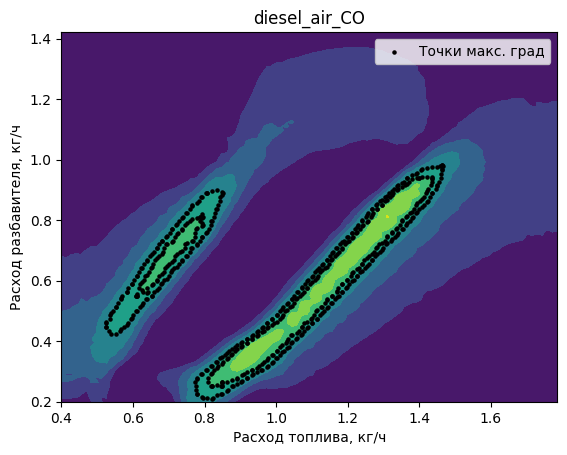

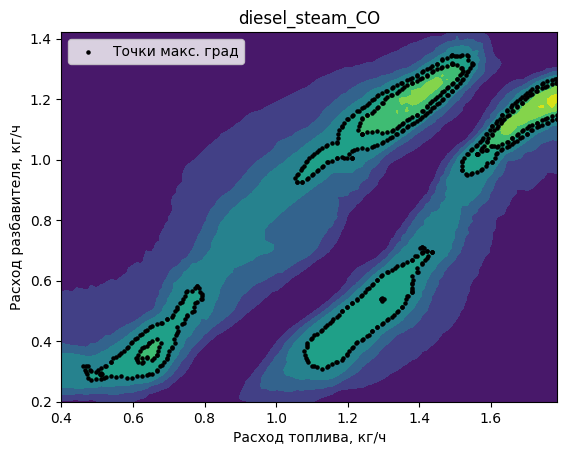

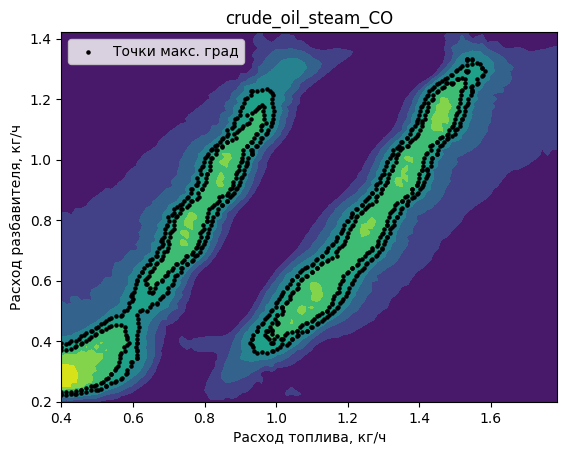

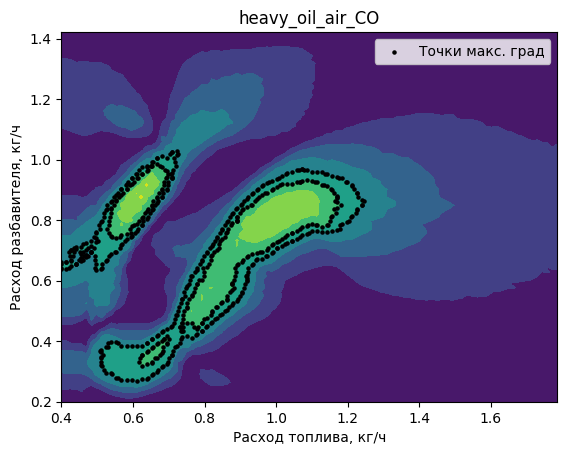

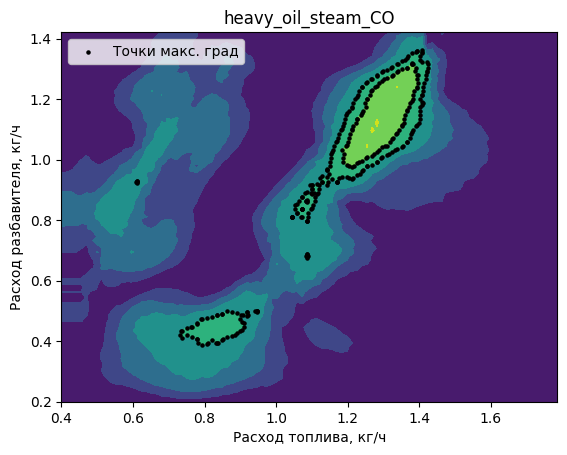

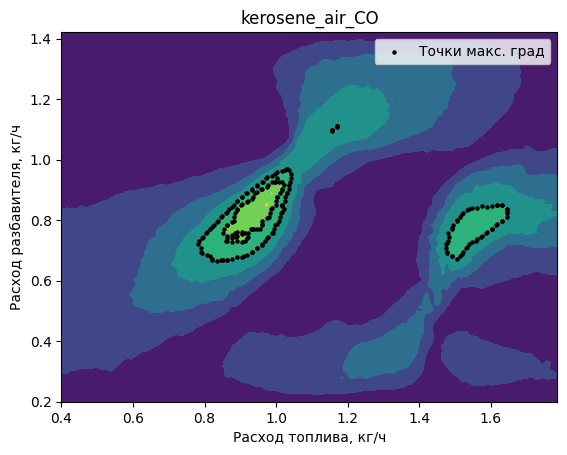

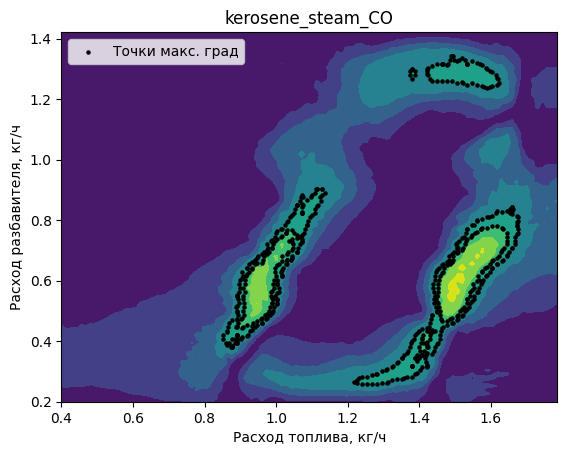

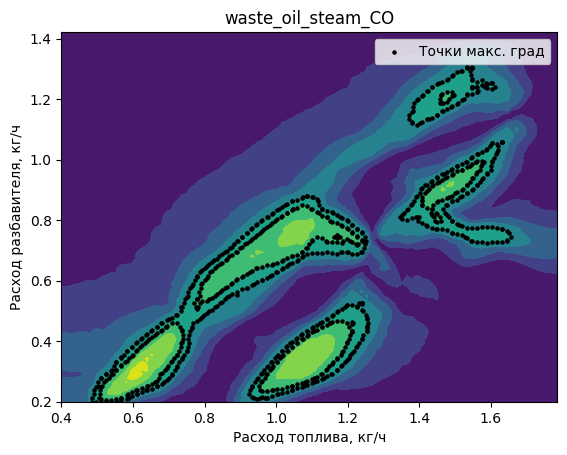

In [7]:
def show_contours(data: Mapping[FuelCombination, ApproxData | DiffData], contour_level) -> None:
    contour_data = get_contours(data, contour_level)
        
    for fuel_combination in data:
        x, y, surf = data[fuel_combination]
        x_level, y_level = contour_data[fuel_combination]
        
        plt.contourf(x, y, surf)
        plt.title(fuel_combination)
        plt.scatter(x_level, y_level, c='black', s=5, label='Точки макс. град')
        plt.xlabel('Расход топлива, кг/ч')
        plt.ylabel('Расход разбавителя, кг/ч')
        plt.legend()
        plt.show()
        
        plt.close()

show_contours(get_diff_data(), 4)

C:\Users\Mark\AppData\Local\Temp\ipykernel_12300\3117077952.py:13: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


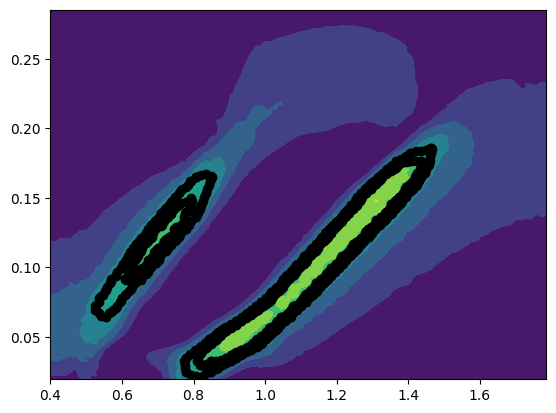

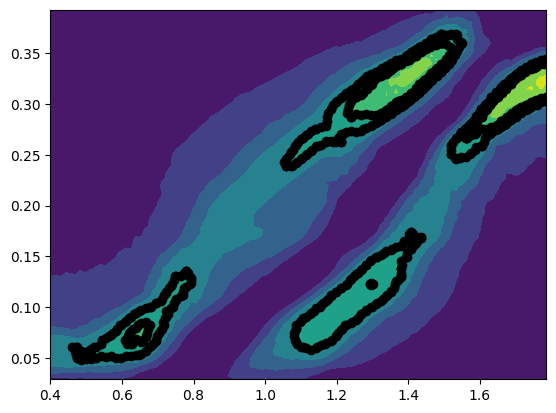

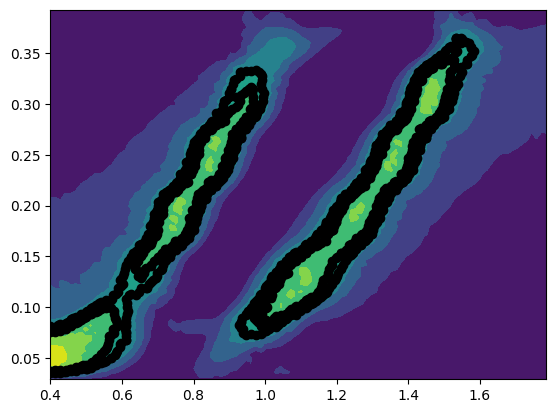

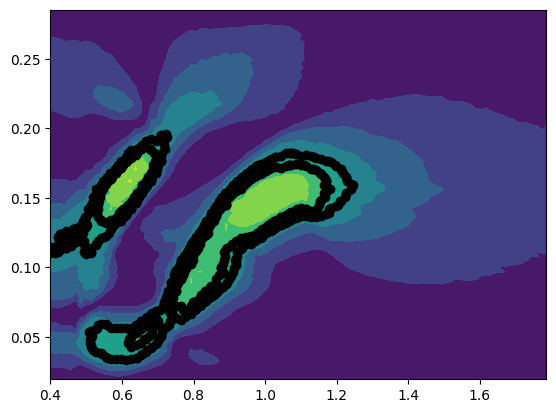

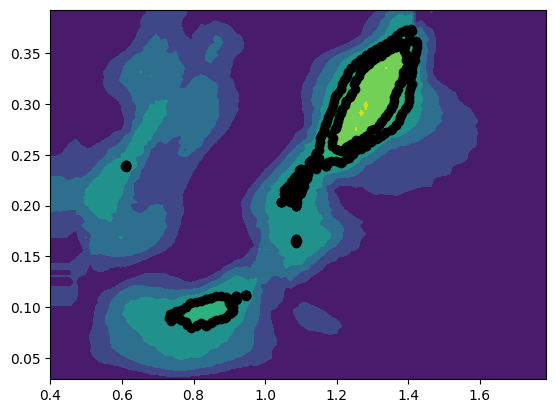

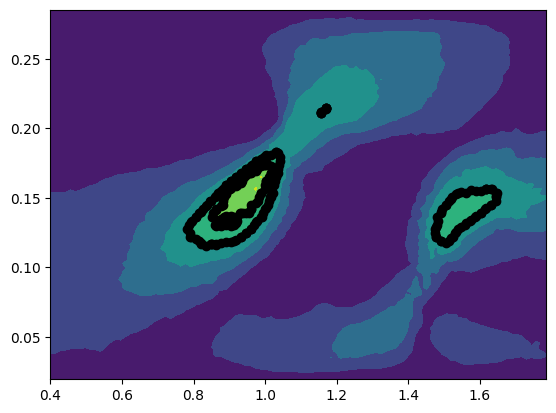

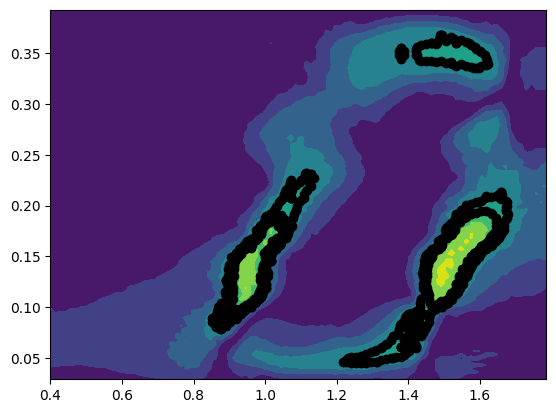

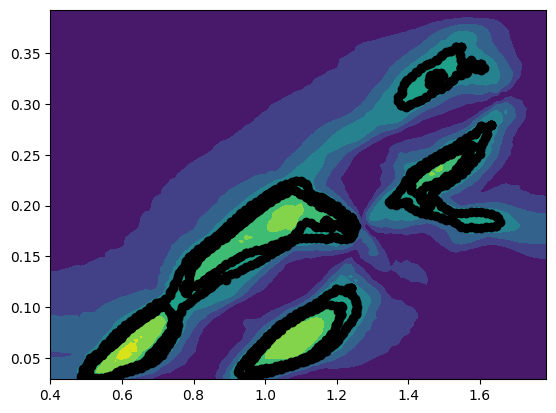

In [8]:
def show_contours(data: Mapping[FuelCombination, ApproxData | DiffData], contour_level) -> None:
    contour_data = get_contours(data, contour_level)
        
    for fuel_combination in data:
        x, y, surf = data[fuel_combination]
        x_level, y_level = contour_data[fuel_combination]
        
        plt.contourf(x, y, surf)

        plt.scatter(x_level, y_level, c='black')
        plt.show()
        plt.close()

show_contours(get_diff_data(J=True), 4)

# Классификация градиентных линий

## SVM

In [9]:
fuel_consumption: TypeAlias = float
additive_consumption: TypeAlias = float

class TrainLevelPoints(NamedTuple):
    points: list[list[fuel_consumption, additive_consumption]]
    point_type: list[int]

def get_train_data() -> Mapping[FuelCombination, TrainLevelPoints]:
    train_data = {
    'diesel_air_CO': (
        [[1.4, 0.9], [0.9, 0.3], [0.58, 0.47], [0.8, 0.8]], 
        [0, 0, 1, 1]
    ),
    'diesel_steam_CO': (
        [[1.6, 1], [1.2, 0.4], [1.4, 1.2], [0.6, 0.4]], 
        [0, 0, 1, 1]
    ),
    'crude_oil_steam_CO': (
        [[1.5, 1.2], [1.1, 0.6], [0.9, 1.1], [0.4, 0.3], [1, 1.25]], 
        [0, 0, 1, 1, 1]
    ),
    'heavy_oil_air_CO': (
        [[1.0, 0.8], [0.6, 0.3], [0.7, 1], [0.5, 0.75]], 
        [0, 0, 1, 1]
    ),
    'heavy_oil_steam_CO': (
        [[1.4, 1.3], [1.2, 1], [0.5, 0.8], [0.7, 1.1]], 
        [0, 0, 1, 1]
    ),
    'kerosene_air_CO': (
        [[1.3, 0.3], [1.5, 0.7], [1.4, 1.4], [0.4, 0.4]], 
        [0, 0, 1, 1]
    ),
    'kerosene_steam_CO': (
        [[1.6, 0.7], [1.4, 0.3], [1.2, 1.0], [0.8, 0.4]], 
        [0, 0, 1, 1]
    ),
    'waste_oil_steam_CO': (
        [[1.1, 0.3], [1.6, 0.8], [1.4, 0.8], [0.6, 0.2], [1.4, 1.2], [1.2, 0.7]], 
        [0, 0, 0, 1, 1, 1]
    ),}
    return train_data
    

C:\Users\Mark\AppData\Local\Temp\ipykernel_12300\3117077952.py:13: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


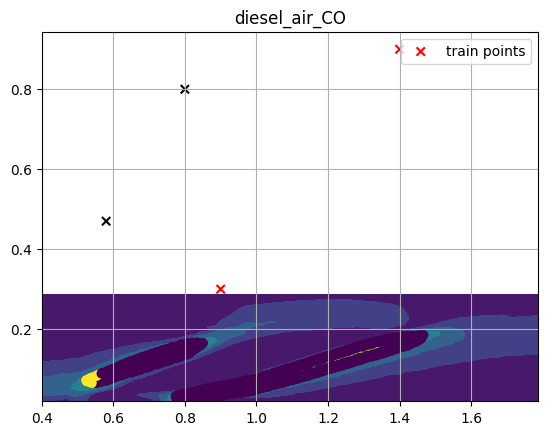

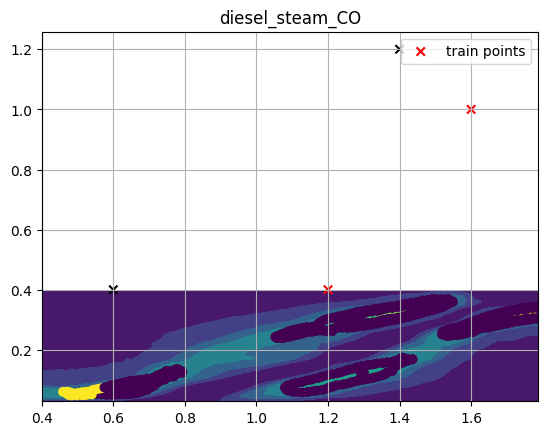

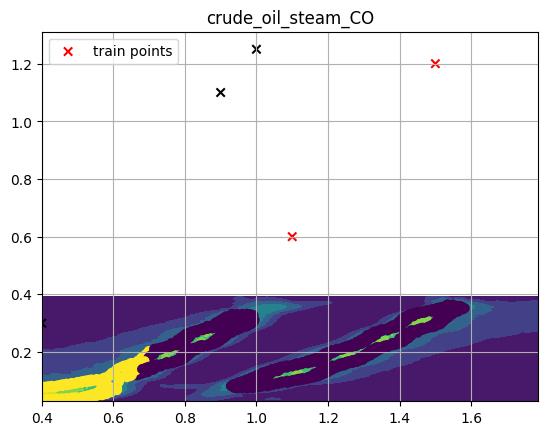

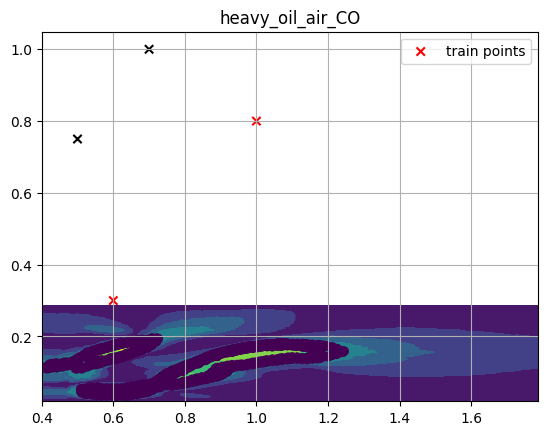

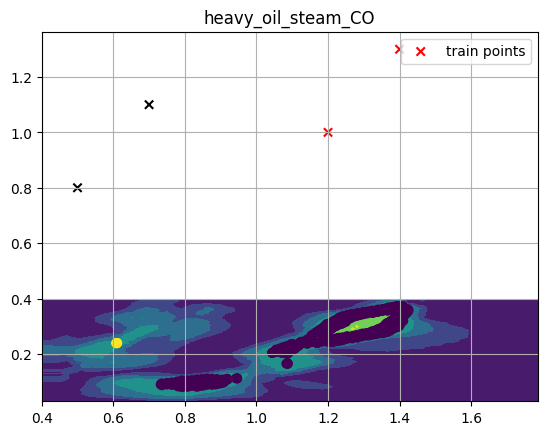

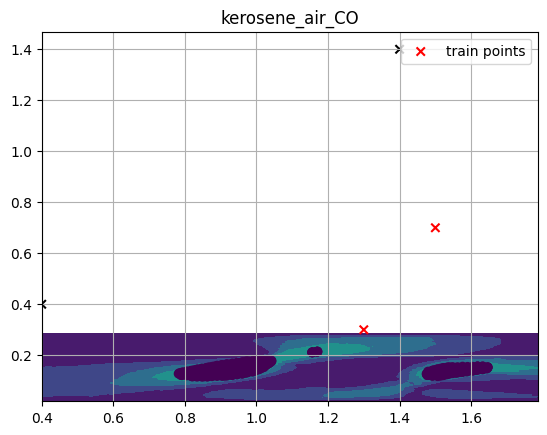

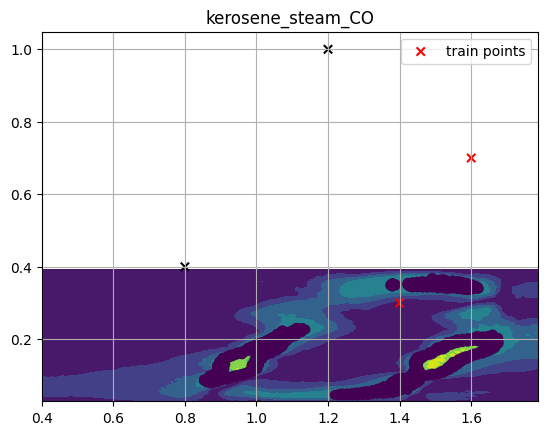

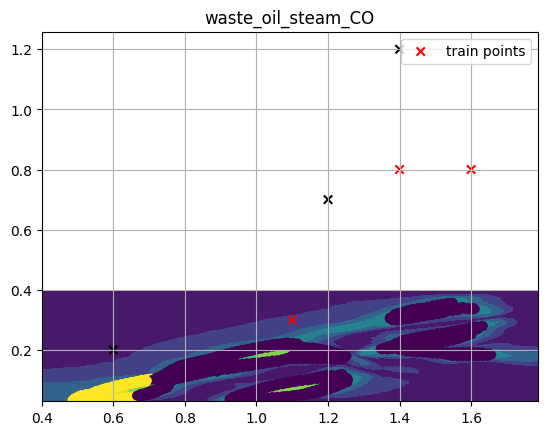

In [10]:
def show_classification_result(data: Mapping[FuelCombination, DiffData], contour_level: int) -> None:
    contour_data = get_contours(data, contour_level)
    train_data = get_train_data()
        
    for fuel_combination in data:
        x, y, surf = data[fuel_combination]
        xy_train, point_type = train_data[fuel_combination]
        x_level, y_level = contour_data[fuel_combination]
        
        clf = svm.LinearSVC(dual="auto").fit(xy_train, point_type)
   
        xy_level = [list(xy) for xy in zip(x_level, y_level)]

        clf_predict = clf.predict(xy_level)

        x_train = [xy[0] for xy in xy_train]
        y_train = [xy[1] for xy in xy_train]
        
        plt.contourf(x, y, surf)
        plt.scatter(x_level, y_level, c=clf_predict)
        plt.scatter(x_train, y_train, marker='x', c=['black' if type == 1 else 'red' for type in point_type], label='train points')
        
        plt.legend()
        plt.title(fuel_combination)
        plt.grid()
        
        plt.show()
        plt.close()
        
show_classification_result(get_diff_data(J=True), 4)       

## DBSCAN

C:\Users\Mark\AppData\Local\Temp\ipykernel_12300\3117077952.py:13: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


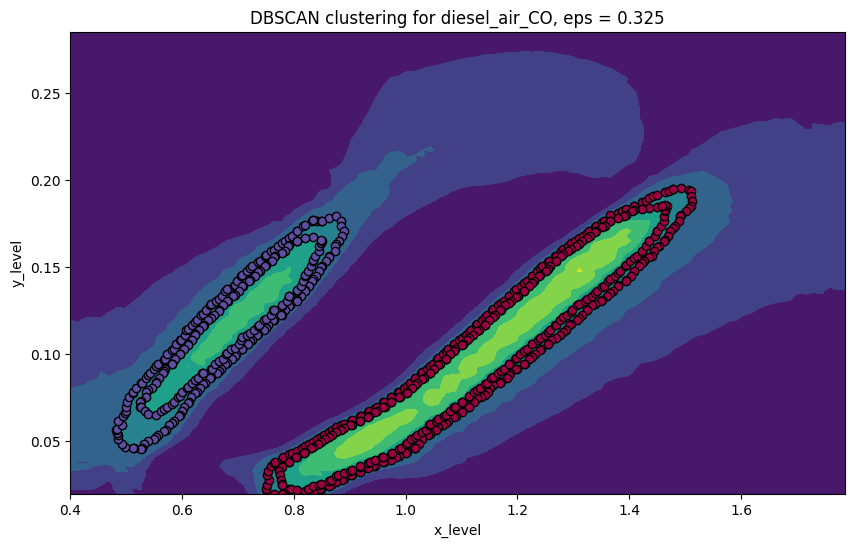

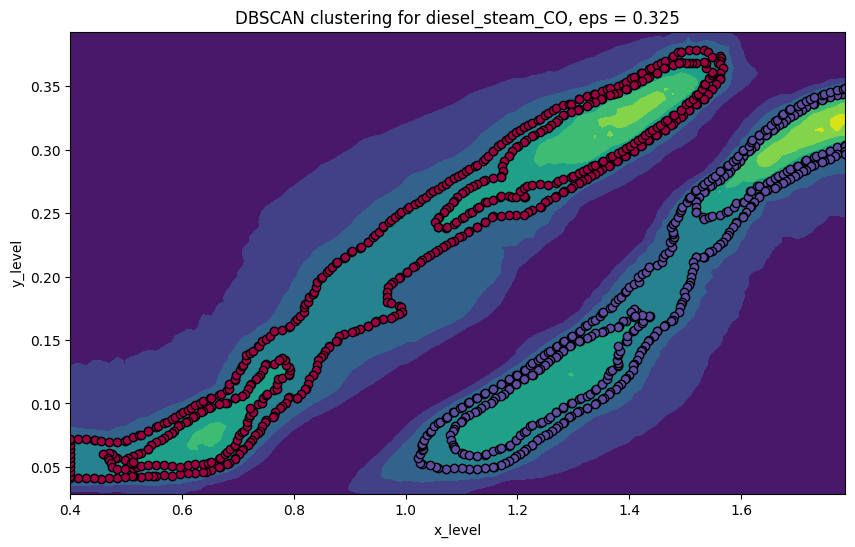

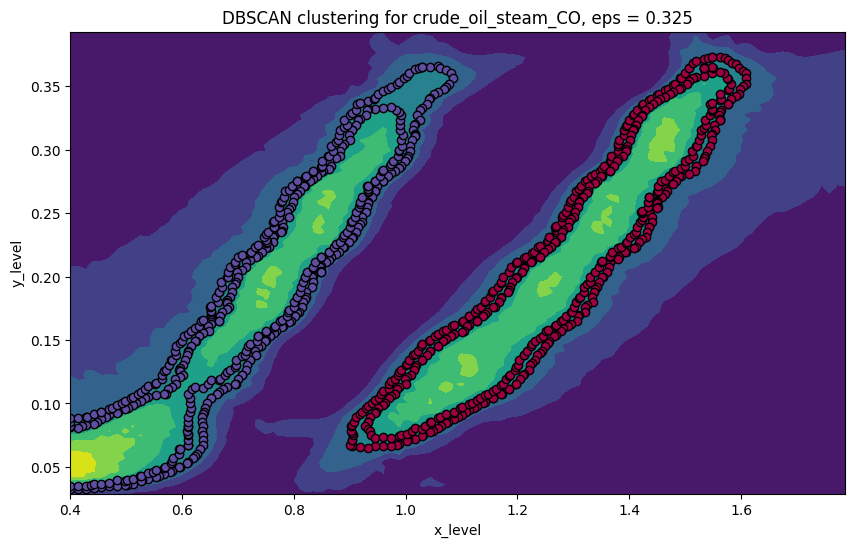

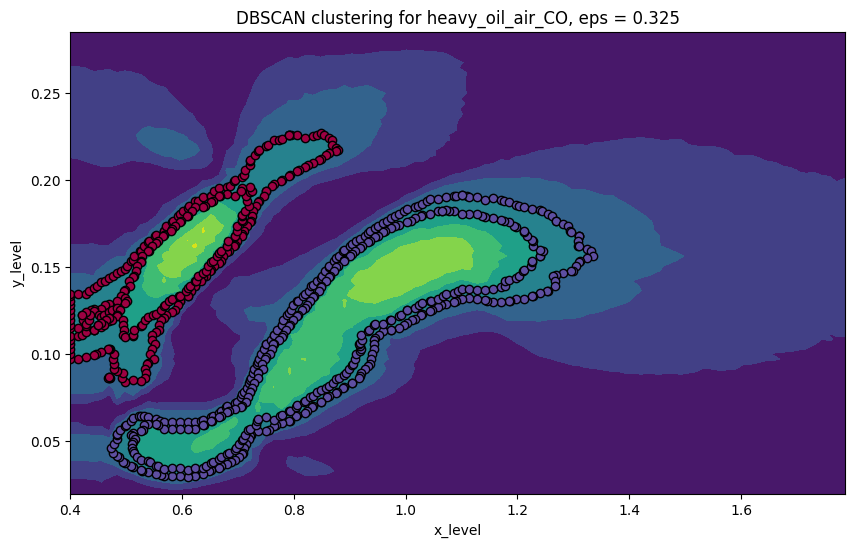

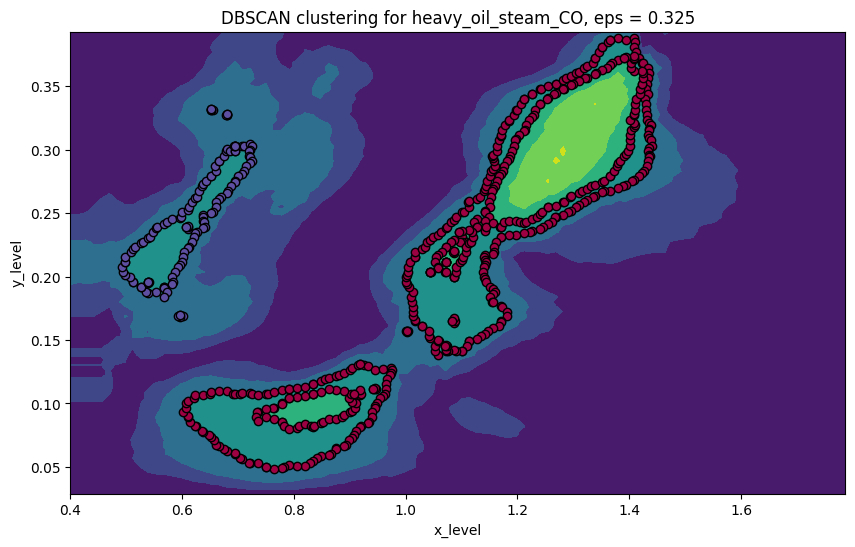

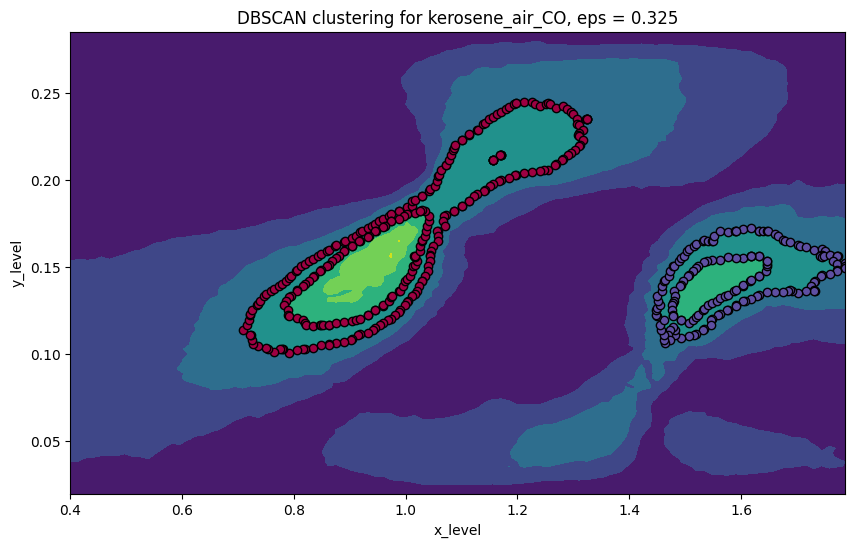

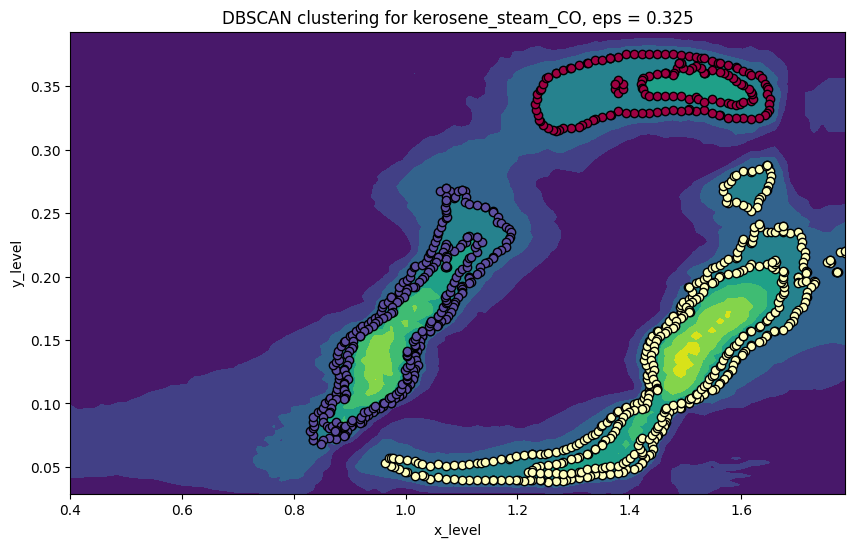

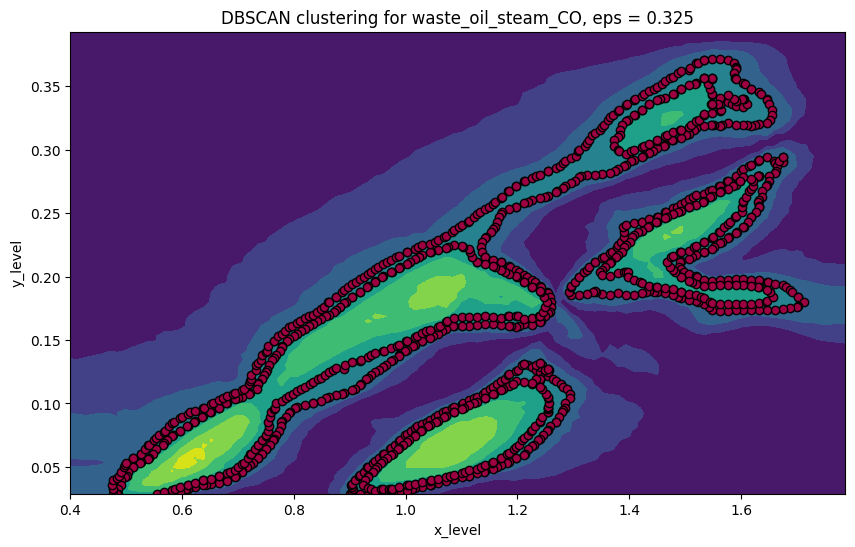

In [11]:
def show_DBSCAN_result(data: Mapping[FuelCombination, DiffData], contour_level: int) -> None:
    contour_data = get_contours(data, contour_level)
    for fuel_combination in data:
        x, y, surf = data[fuel_combination]
        x_level, y_level = contour_data[fuel_combination]
        points = np.column_stack((x_level, y_level))
        
        scaler = StandardScaler()
        points_normalized = scaler.fit_transform(points)
        
        eps = 0.325
        dbscan = DBSCAN(eps=eps)
        labels = dbscan.fit_predict(points_normalized)
        # Визуализация
        plt.figure(figsize=(10, 6))
        unique_labels = set(labels)
        colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
        
        for k, col in zip(unique_labels, colors):
            if k == -1:
                col = [0, 0, 0, 1]  # Черный цвет для шумовых точек

            class_member_mask = (labels == k)
            
            xy = points[class_member_mask]
            plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col), markeredgecolor='k', markersize=6)
        plt.contourf(x, y, surf)
        plt.title(f'DBSCAN clustering for {fuel_combination}, eps = {eps}')
        plt.xlabel('x_level')
        plt.ylabel('y_level')
        plt.show()
show_DBSCAN_result(get_diff_data(J=True), 3)

## Классификация с помощью разделяющей плоскости

In [12]:
class LinearCoeffs(NamedTuple):
    a: float
    b: float

class MinPoints(NamedTuple):
    x: np.ndarray
    y: np.ndarray
    
def _linear(x, a, b):
    return a * x + b


def _get_min_CO(data: Mapping[FuelCombination, ApproxData]) -> Mapping[FuelCombination, MinPoints]:
    min_CO = {}
    
    for fuel_combination in data:
        fuel, additive, surf = data[fuel_combination]
        df = pd.DataFrame(surf, columns=fuel, index=additive)
        df = df.idxmin(axis=1)
        min_x = list(df)
        min_y = list(df.index)
        min_CO[fuel_combination] = min_x, min_y
    return min_CO

def get_linear_coeffs_min_CO(data: Mapping[FuelCombination, ApproxData], J: bool=False) -> Mapping[FuelCombination, LinearCoeffs]:
    coeffs = {}
    if J:
        data = _replace_additive_column_with_J_column(data)
        min_CO = _get_min_CO(data)
    else:
        min_CO = _get_min_CO(data)
    
    for fuel_combination in min_CO:
        min_x, min_y = min_CO[fuel_combination]
        params, _ = curve_fit(_linear, min_x, min_y)
        a, b = params
        coeffs[fuel_combination] = a, b
        
    return coeffs

get_linear_coeffs_min_CO(get_rbf_data(), J=True)
        

{'diesel_air_CO': (0.3868081772258332, -0.23596877715122536),
 'diesel_steam_CO': (0.36256052004673484, -0.24126601306597242),
 'crude_oil_steam_CO': (0.6390482739756126, -0.3865978373113179),
 'heavy_oil_air_CO': (0.47608913736908465, -0.21817630807961544),
 'heavy_oil_steam_CO': (0.7668460749656532, -0.4819790625067817),
 'kerosene_air_CO': (0.5463492191255098, -0.5277172546331537),
 'kerosene_steam_CO': (0.9368213301658875, -1.0024749972545903),
 'waste_oil_steam_CO': (0.36465175546926687, -0.2362967180876555)}

In [13]:
class RightLinePoints(NamedTuple):
    a: float
    b: float

def _classify_by_line(MinPoints, LinearCoeffs) -> np.array:
    x, y = MinPoints
    a, b = LinearCoeffs
    result = y - a * x - b
    
    classification = np.where(result > 0, 1, 2)
    return classification


In [14]:
def _get_class(x: np.ndarray, y: np.ndarray, predicted_class: np.ndarray, class_number: int) -> LevelPoints:
    x_selected = []
    y_selected = []
    
    for i in range(len(predicted_class)):
        if predicted_class[i] == class_number:
            x_selected.append(x[i])
            y_selected.append(y[i])
    return np.array(x_selected), np.array(y_selected)



def get_linear_coeffs_div_line(data: Mapping[FuelCombination, DiffData], contour_level: int, J: bool=False, cls: int=2) -> Mapping[FuelCombination, MinPoints]:
    linear_coeffs = {}
    if J:
        min_coeffs = get_linear_coeffs_min_CO(get_rbf_data(), J=True)
        
        contour_data = get_contours(get_diff_data(J=True), contour_level)
    else:
        min_coeffs = get_linear_coeffs_min_CO(get_rbf_data())
        contour_data = get_contours(data, contour_level)
    
    for fuel_combination in data:
        x, y, surf = data[fuel_combination]
        a, b = min_coeffs[fuel_combination]
        x_level, y_level = contour_data[fuel_combination]
        
        classified = _classify_by_line((x_level, y_level), (a, b))
        x_selected, y_selected = _get_class(x_level, y_level, classified, cls)
        params, _ = curve_fit(_linear, x_selected, y_selected)
        a, b = params
        linear_coeffs[fuel_combination] = a, b
        
    return linear_coeffs

get_linear_coeffs_div_line(get_diff_data(), 4, J=True)

C:\Users\Mark\AppData\Local\Temp\ipykernel_12300\3117077952.py:13: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


{'diesel_air_CO': (0.23570537851957796, -0.1662786098985678),
 'diesel_steam_CO': (0.4278380991476136, -0.41927418747681355),
 'crude_oil_steam_CO': (0.4523148659319777, -0.36457125990554623),
 'heavy_oil_air_CO': (0.21149401147275917, -0.07537425903229888),
 'heavy_oil_steam_CO': (0.4371331130247927, -0.2621803279515334),
 'kerosene_air_CO': (0.13707943878056722, -0.07345780937213721),
 'kerosene_steam_CO': (0.5031371715827355, -0.5933989962254997),
 'waste_oil_steam_CO': (0.34033758929374275, -0.28428752512948835)}

C:\Users\Mark\AppData\Local\Temp\ipykernel_12300\3117077952.py:13: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]
C:\Users\Mark\AppData\Local\Temp\ipykernel_12300\3117077952.py:13: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


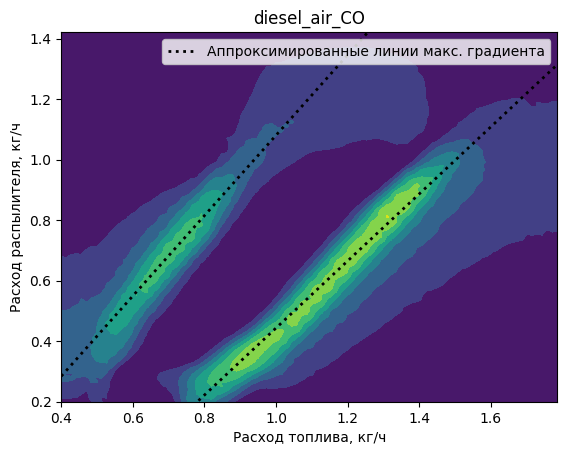

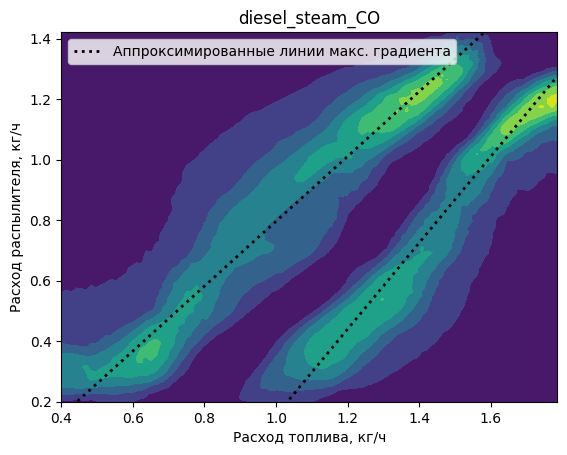

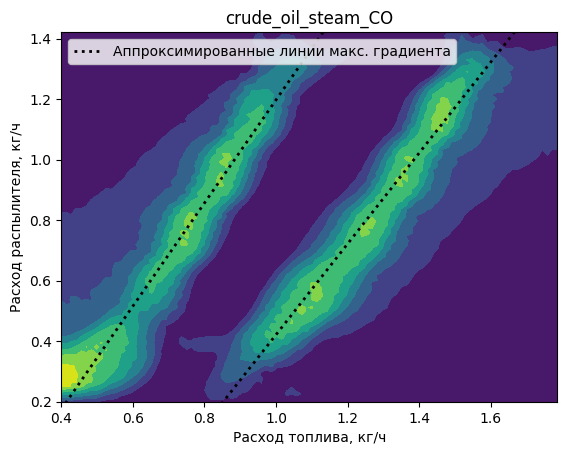

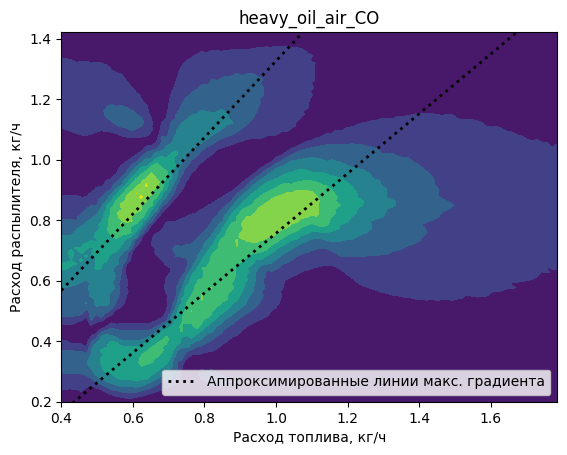

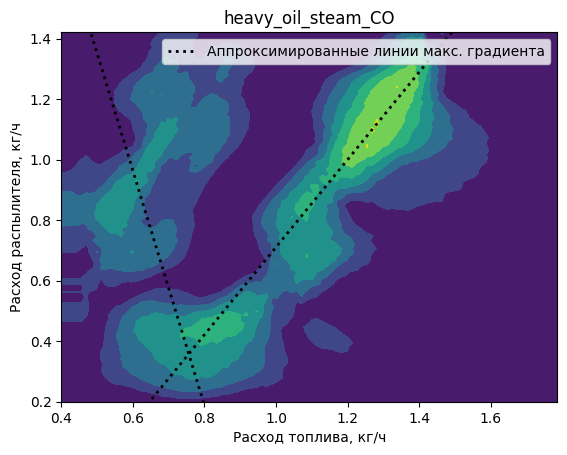

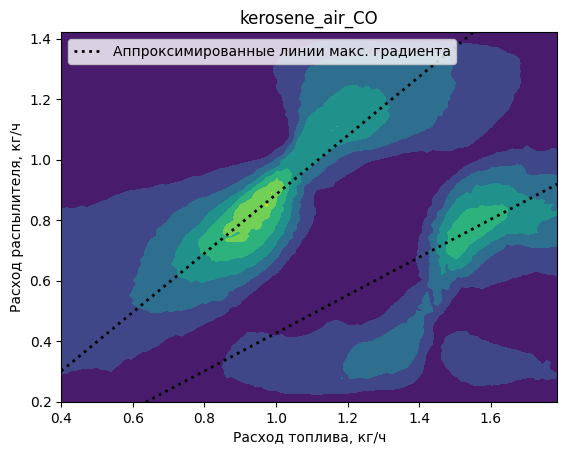

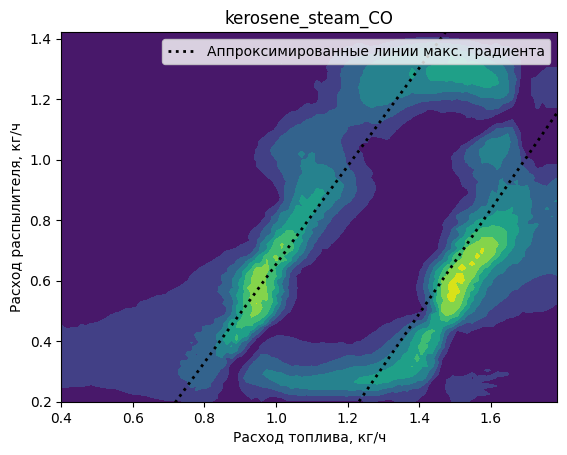

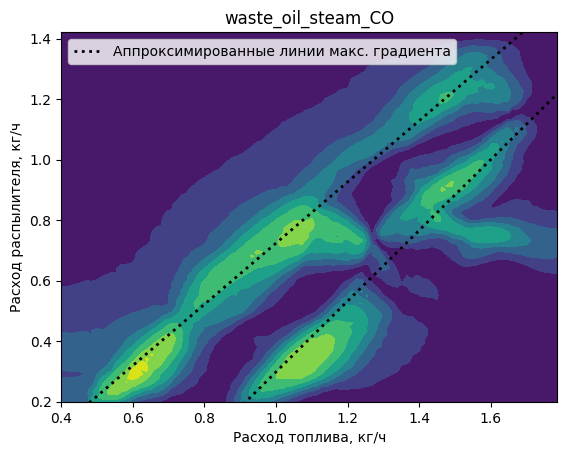

In [15]:
def show_classification_by_div_line(data: Mapping[FuelCombination, DiffData], contour_level: int, J: bool=False) -> None:
    if J:
        min_coeffs = get_linear_coeffs_min_CO(get_rbf_data(), J=True)
        div_line_coeffs = get_linear_coeffs_div_line(data, contour_level, J=True)
        data = get_diff_data(J=True)
        contour_data = get_contours(data, contour_level)
    else:
        min_coeffs = get_linear_coeffs_min_CO(get_rbf_data())
        div_line_coeffs = get_linear_coeffs_div_line(data, contour_level)
        div_line_coeffs_high_line = get_linear_coeffs_div_line(data, contour_level, cls=1)
        contour_data = get_contours(data, contour_level)

    for fuel_combination in data:
        x, y, surf = data[fuel_combination]
        a, b = min_coeffs[fuel_combination]
        a_sel, b_sel = div_line_coeffs[fuel_combination]
        a_sel_hl, b_sel_hl = div_line_coeffs_high_line[fuel_combination]  # Выбор верхней линии макс. град
        min_approx = _linear(x, a, b)
        max_grad = _linear(x, a_sel, b_sel)
        max_grad_hl = _linear(x, a_sel_hl, b_sel_hl)
        x_level, y_level = contour_data[fuel_combination]
        
        classified = _classify_by_line((x_level, y_level), (a, b))
        fig, ax = plt.subplots()
        plt.contourf(x, y, surf)
        #plt.plot(x, min_approx, c='black', linestyle='dashed', linewidth=2, label='мин. CO')
        #plt.scatter(x_level, y_level, c=classified, label='линии уровня')
        plt.plot(x, max_grad, c='black', linestyle='dotted', linewidth=2, label='Аппроксимированные линии макс. градиента')
        plt.plot(x, max_grad_hl, c='black', linestyle='dotted', linewidth=2)
        plt.xlabel('Расход топлива, кг/ч')
        plt.ylabel('Расход распылителя, кг/ч')
        plt.ylim(min(y), max(y))
        plt.title(fuel_combination)
        plt.legend()
        plt.show()
        plt.close()

show_classification_by_div_line(get_diff_data(), 4)

In [16]:
def _get_models(train_data: Mapping[FuelCombination, LevelPoints]) -> Mapping[FuelCombination, svm._classes.LinearSVC]:
    models = {}
    
    for fuel_combination in train_data:
        xy_train, point_type = train_data[fuel_combination]
        
        clf = svm.LinearSVC(dual="auto").fit(xy_train, point_type)
        models[fuel_combination] = clf
    return models

def get_linear_coeffs_grad(contour_data: Mapping[FuelCombination, LevelPoints]) -> Mapping[FuelCombination, LinearCoeffs]:
    coeffs = {}
    train_data = get_train_data()
    models = _get_models(train_data)

    for fuel_combination in contour_data:
        x_level, y_level = contour_data[fuel_combination]
        xy_level = [list(xy) for xy in zip(x_level, y_level)]
       
        clf = models[fuel_combination]
        clf_predict = clf.predict(xy_level)
        
        selected_x, selected_y = _get_class(x_level, y_level, clf_predict, 0)
        params, _ = curve_fit(_linear, selected_x, selected_y)
        a, b = params
        coeffs[fuel_combination] = a, b
    return coeffs

get_linear_coeffs_grad(get_contours(get_diff_data(), 4))

C:\Users\Mark\AppData\Local\Temp\ipykernel_12300\3117077952.py:13: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


{'diesel_air_CO': (1.108080061328729, -0.6644828672860821),
 'diesel_steam_CO': (1.4271365086260723, -1.2727857345761684),
 'crude_oil_steam_CO': (1.501792702634031, -1.0802456146186317),
 'heavy_oil_air_CO': (0.9559806298598701, -0.19987019352647403),
 'heavy_oil_steam_CO': (1.427494869165731, -0.7116563613425895),
 'kerosene_air_CO': (0.6267048250501233, -0.19988304479339425),
 'kerosene_steam_CO': (1.4035057082785767, -1.5428272474934208),
 'waste_oil_steam_CO': (1.1613687004346382, -0.8845928332035895)}

In [17]:
class LinearCoeffs(NamedTuple):
    a: float
    b: float

def _get_models(train_data: Mapping[FuelCombination, LevelPoints]) -> Mapping[FuelCombination, svm._classes.LinearSVC]:
    models = {}
    
    for fuel_combination in train_data:
        xy_train, point_type = train_data[fuel_combination]
        
        clf = svm.LinearSVC(dual="auto").fit(xy_train, point_type)
        models[fuel_combination] = clf
    return models



def _linear(x, a, b):
    return a * x + b
    

def get_linear_coeffs_grad(contour_data: Mapping[FuelCombination, LevelPoints]) -> Mapping[FuelCombination, LinearCoeffs]:
    coeffs = {}
    train_data = get_train_data()
    models = _get_models(train_data)

    for fuel_combination in contour_data:
        x_level, y_level = contour_data[fuel_combination]
        xy_level = [list(xy) for xy in zip(x_level, y_level)]
       
        clf = models[fuel_combination]
        clf_predict = clf.predict(xy_level)
        
        selected_x, selected_y = _get_class(x_level, y_level, clf_predict, 0)
        params, _ = curve_fit(_linear, selected_x, selected_y)
        a, b = params
        coeffs[fuel_combination] = a, b
    return coeffs

get_linear_coeffs_grad(get_contours(get_diff_data(J=True), 4))

C:\Users\Mark\AppData\Local\Temp\ipykernel_12300\3117077952.py:13: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


{'diesel_air_CO': (0.07248084681369027, 0.03372265655553486),
 'diesel_steam_CO': (0.2310282018106961, -0.06841537864652827),
 'crude_oil_steam_CO': (0.12523625871791777, 0.07963093083240769),
 'heavy_oil_air_CO': (0.05897775188708654, 0.0778818137074313),
 'heavy_oil_steam_CO': (0.4309487999002052, -0.25441441289850947),
 'kerosene_air_CO': (-0.0001787933189412172, 0.14903299293000172),
 'kerosene_steam_CO': (0.08218780698669914, 0.05454312443081433),
 'waste_oil_steam_CO': (0.21885302091563785, -0.08664586623261927)}

C:\Users\Mark\AppData\Local\Temp\ipykernel_12300\3117077952.py:13: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


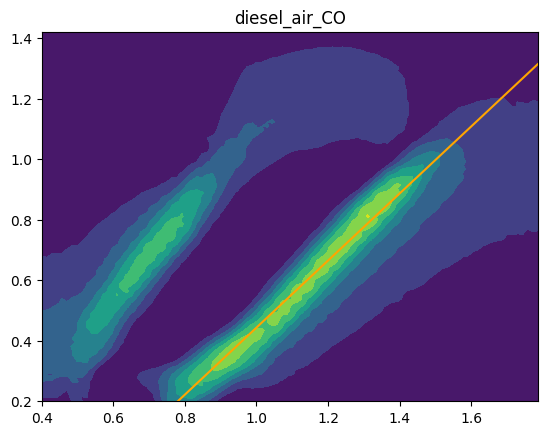

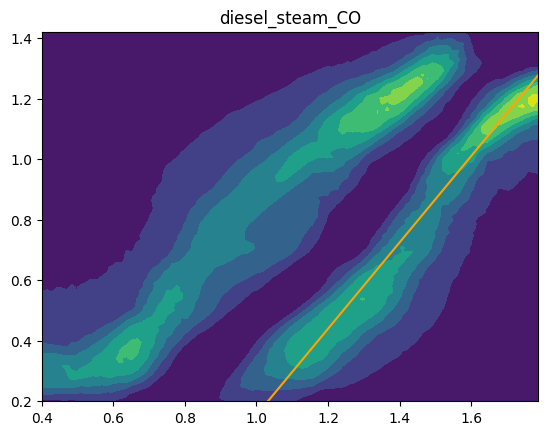

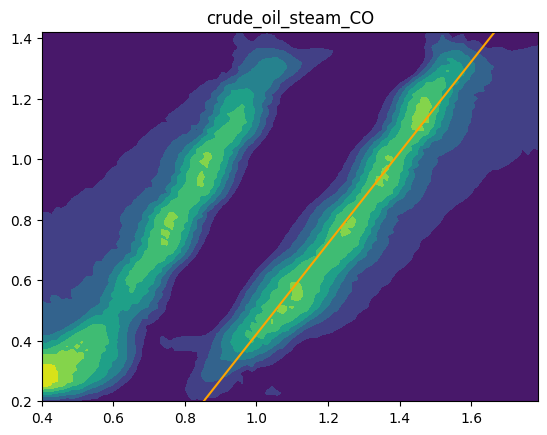

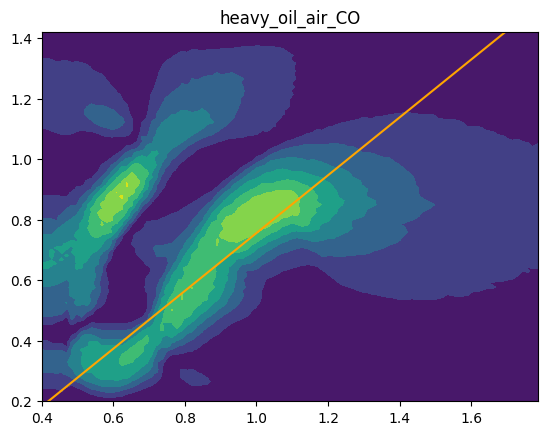

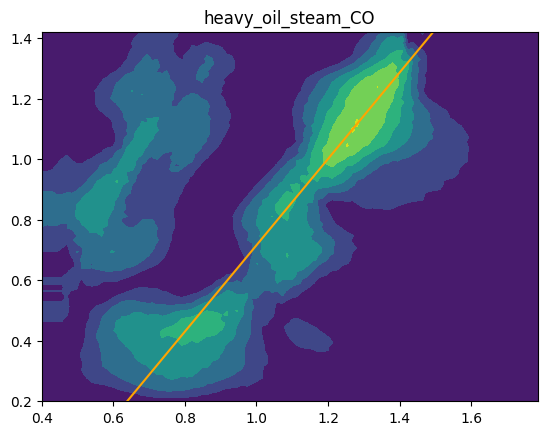

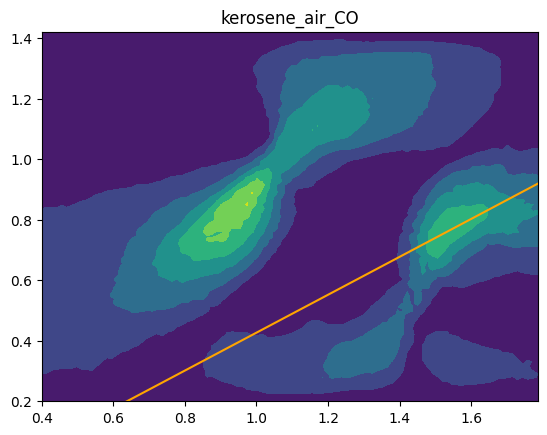

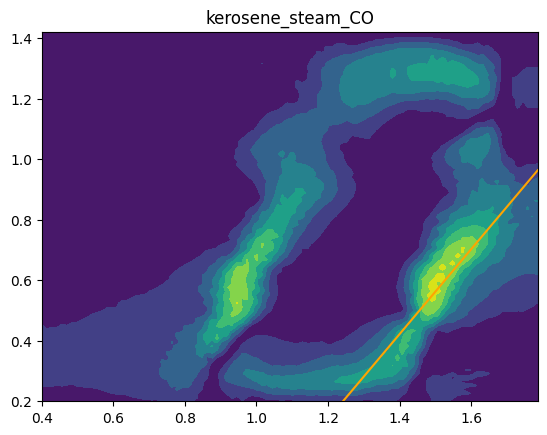

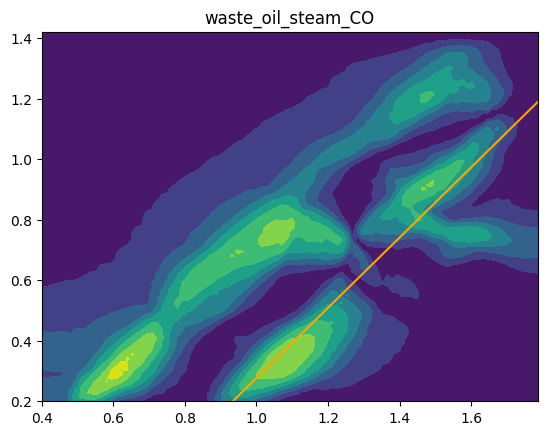

In [18]:
def show_approx_equations() -> None:
    diffs = get_diff_data()
    coeffs = get_linear_coeffs_grad(get_contours(diffs, 4))

    for fuel_combination in diffs:
        fuel_cons, add_cons_diff, diff = diffs[fuel_combination]
        approx = _linear(fuel_cons, *coeffs[fuel_combination])
        
        plt.title(fuel_combination)
        
        plt.contourf(fuel_cons, add_cons_diff, diff)
        plt.plot(fuel_cons, approx, c='orange')
        plt.ylim(min(add_cons_diff), max(add_cons_diff))
        plt.show()
        plt.close()

show_approx_equations()

In [19]:
def get_mean_coeffs(
    grad_coeffs: Mapping[FuelCombination, LinearCoeffs], 
    min_coeffs: Mapping[FuelCombination, LinearCoeffs]
) -> Mapping[FuelCombination, LinearCoeffs]:
    coeffs = {}
    
    for fuel_combination in min_coeffs:
        a = (grad_coeffs[fuel_combination][0] + min_coeffs[fuel_combination][0]) / 2
        b = (grad_coeffs[fuel_combination][1] + min_coeffs[fuel_combination][1]) / 2
        coeffs[fuel_combination] = a, b
    return coeffs
        
get_mean_coeffs(get_linear_coeffs_grad(get_contours(get_diff_data(), 4)), get_linear_coeffs_min_CO(get_rbf_data()))       

C:\Users\Mark\AppData\Local\Temp\ipykernel_12300\3117077952.py:13: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


{'diesel_air_CO': (1.441574805609451, -0.8109842180683565),
 'diesel_steam_CO': (1.3168192227353974, -0.9754267935810758),
 'crude_oil_steam_CO': (1.8110964407421024, -1.1180566756071773),
 'heavy_oil_air_CO': (1.5625025855895487, -0.53165287327681),
 'heavy_oil_steam_CO': (1.983194135719215, -1.0894777901775552),
 'kerosene_air_CO': (1.5553973222755735, -1.233629203775459),
 'kerosene_steam_CO': (2.2600817911551125, -2.3764574058082326),
 'waste_oil_steam_CO': (1.1877121500507979, -0.7734308559225483)}

C:\Users\Mark\AppData\Local\Temp\ipykernel_12300\3117077952.py:13: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


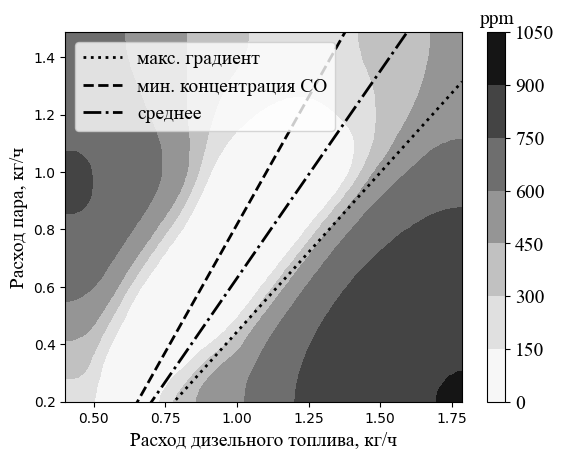

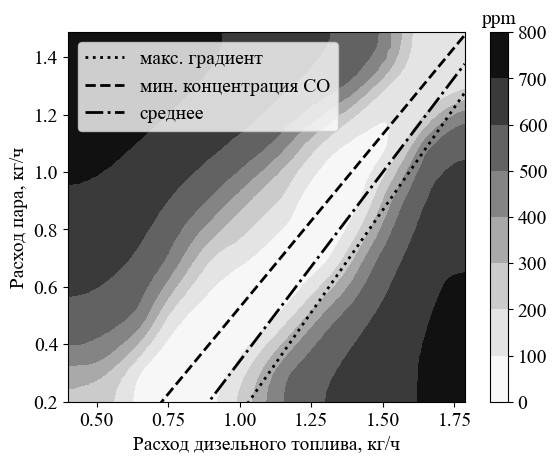

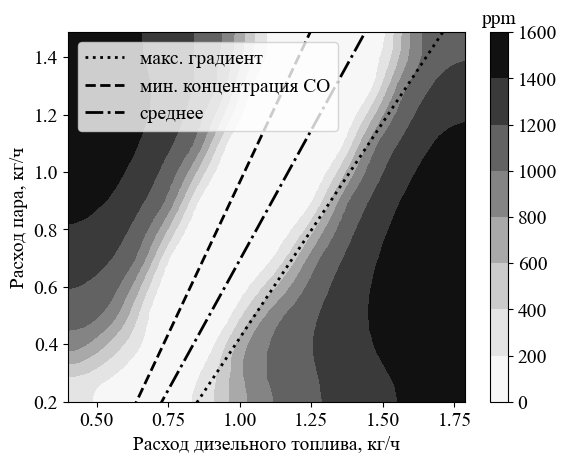

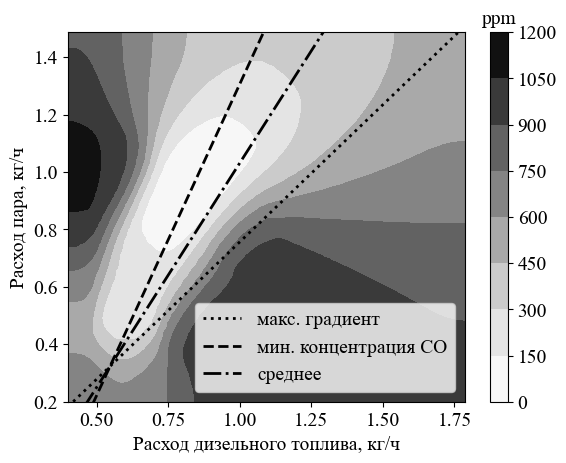

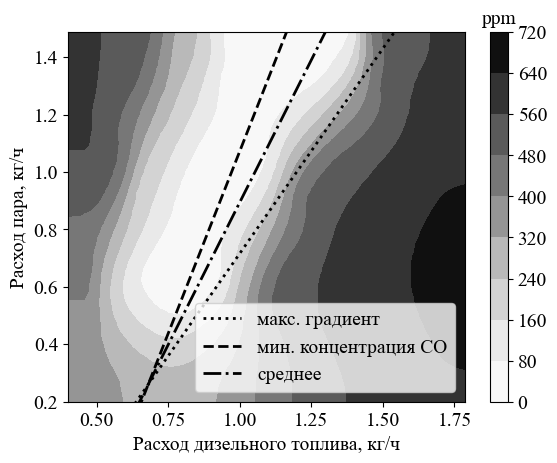

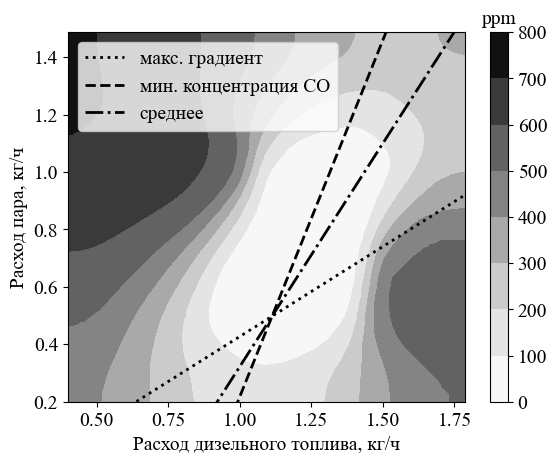

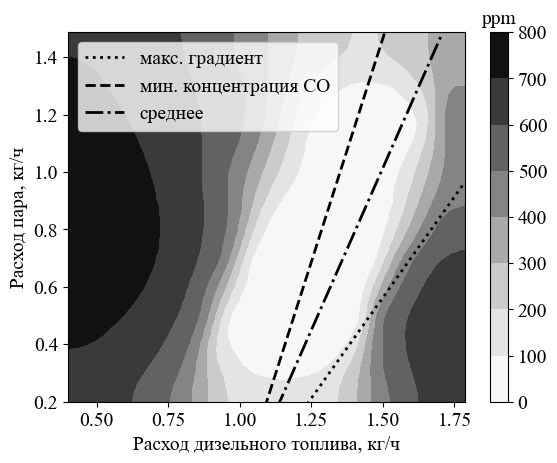

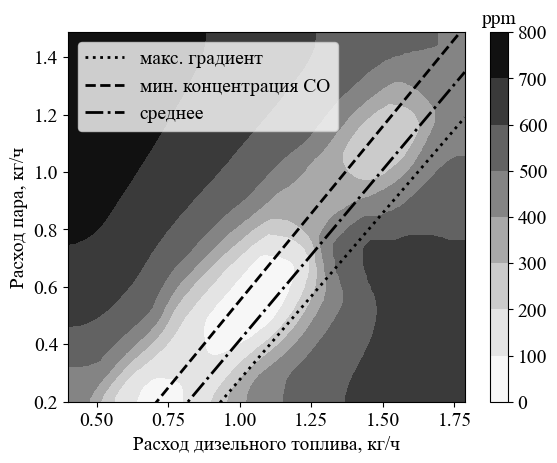

In [20]:
def show_result_equations() -> None:
    surfs = get_rbf_data()
    grad_coeffs = get_linear_coeffs_grad(get_contours(get_diff_data(), 4))
    min_coeffs = get_linear_coeffs_min_CO(get_rbf_data())
    mean_coeffs = get_mean_coeffs(grad_coeffs, min_coeffs)

    for fuel_combination in surfs:
        fuel_cons, add_cons_diff, diff = surfs[fuel_combination]
        grad_approx = _linear(fuel_cons, *grad_coeffs[fuel_combination])
        min_approx = _linear(fuel_cons, *min_coeffs[fuel_combination])
        mean_approx = _linear(fuel_cons, *mean_coeffs[fuel_combination])
        
        fig, ax = plt.subplots()
        font = {'family': 'Times New Roman', 'size': 14}
        plt.rc('font', **font)
        plt.contourf(fuel_cons, add_cons_diff, diff, cmap='Greys')
        plt.plot(fuel_cons, grad_approx, c='black', linestyle='dotted', linewidth=2, label='макс. градиент')
        plt.plot(fuel_cons, min_approx, c='black', linestyle='dashed', linewidth=2, label='мин. концентрация CO')
        plt.plot(fuel_cons, mean_approx, c='black', linestyle='dashdot', linewidth=2, label='среднее')
        clb = plt.colorbar()
        clb.ax.set_title('ppm', fontdict={'fontname': 'Times New Roman', 'fontsize': 14})
        ax.set_xlabel('Расход дизельного топлива, кг/ч', fontdict={'fontname': 'Times New Roman', 'fontsize': 14})
        ax.set_ylabel('Расход пара, кг/ч', fontdict={'fontname': 'Times New Roman', 'fontsize': 14})
        plt.legend()
        plt.ylim(min(add_cons_diff), max(add_cons_diff))
        #plt.title(fuel_combination)
        plt.show()
        plt.close()
        
                                          
show_result_equations() 

# Расчет J

In [21]:
def _split_string(input_string):
    separated = input_string.split('_')
    if 'oil' in separated:
        separated[0] = separated[0] + '_oil'
        separated.pop(1)
        
    return tuple(separated)

def get_df_with_J() -> Mapping[FuelCombination, pd.DataFrame]:
    surfs = get_rbf_data()
    dfs = {}
    
    for name in surfs:
        ex = ExperimentData()
        fuel_name, additive_name, component_name = _split_string(name)
        ex.get_experiment_data(fuel_name, additive_name, component_name)
        fuel_axis, additive_axis, approx_surf = surfs[name]
        df = ex.convert_approximated_surface_to_df(
            fuel_axis,
            additive_axis,
            approx_surf
        )
        dfs[name] = df
    dfs_J = _replace_additive_column_with_J_column(dfs)

    return dfs_J

def _get_surf_from_df(dfs: Mapping[FuelCombination, pd.DataFrame]) -> Mapping[FuelCombination, ApproxData]:
    surfs_with_J = {}
    dfs_J = get_df_with_J()
    for name in dfs_J:
        df = dfs_J[name]
        fuel_set = sorted(set(list(df["F_fuel"])))
        additive_set = sorted(set(list(df['J'])))
    
        arr = np.empty((len(additive_set), len(fuel_set)))
        arr[:] = np.nan
    
        # Создаем словарь для того, чтобы запомнить положение элемента расхода (F_fuel, F_air/F_steam)
        fuel_positions = dict()
        for index, element in enumerate(fuel_set):
            fuel_positions[element] = index
    
        additive_positions = dict()
        for index, element in enumerate(additive_set):
            additive_positions[element] = index
    
        for row in df.itertuples():
            fuel_value = row[1]
            add_value = row[4]
            component_value = row[3]
            # Узнаем из словаря порядок значения в списке для заполнения массива
            arr_fuel_pos = fuel_positions[fuel_value]
            arr_add_pos = additive_positions[add_value]
    
            arr[arr_add_pos][arr_fuel_pos] = component_value
    
        #arr = np.flipud(arr)
        surfs_with_J[name] = fuel_set, additive_set, arr
    return surfs_with_J
    

# Графики условий оптимального режима

C:\Users\Mark\AppData\Local\Temp\ipykernel_12300\3117077952.py:13: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


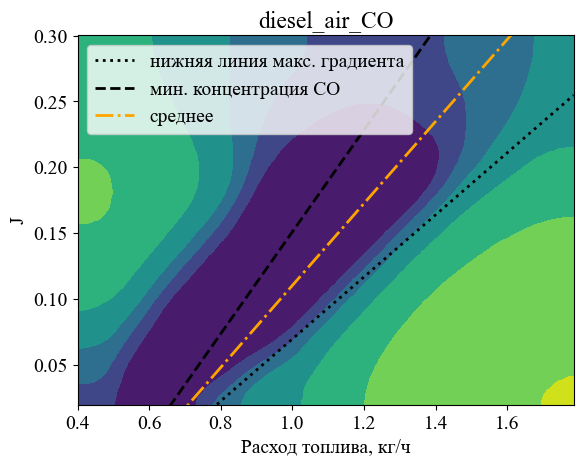

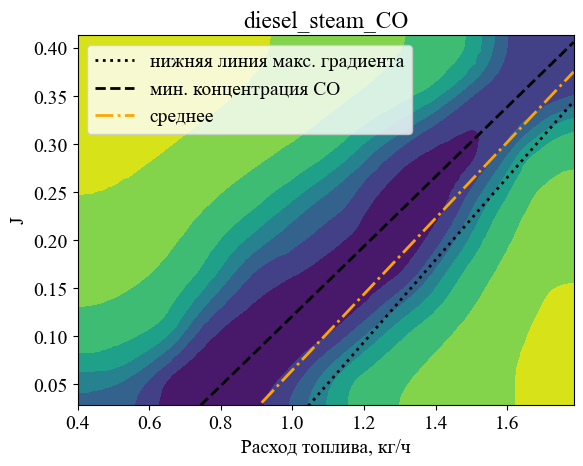

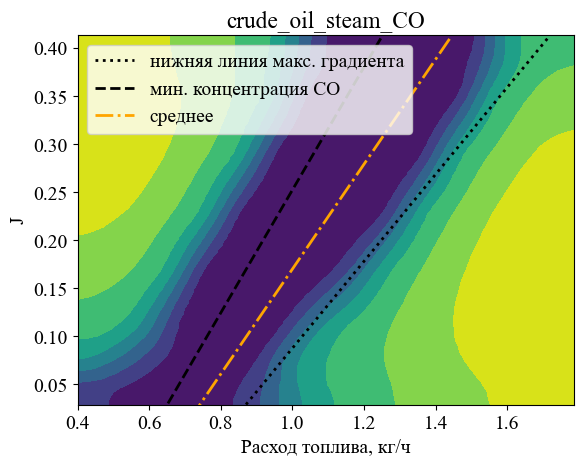

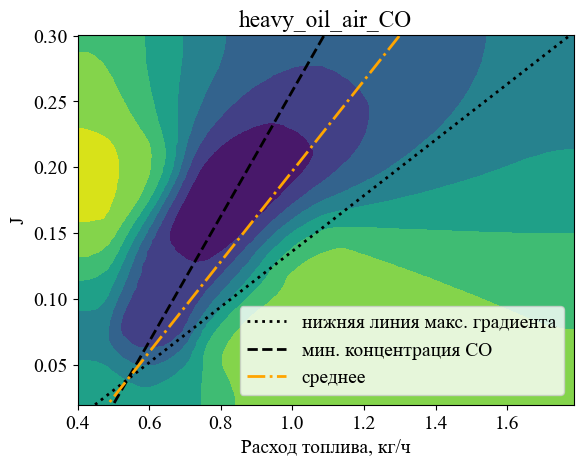

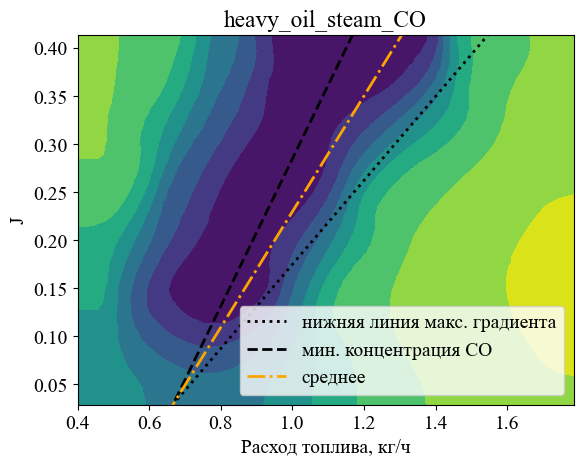

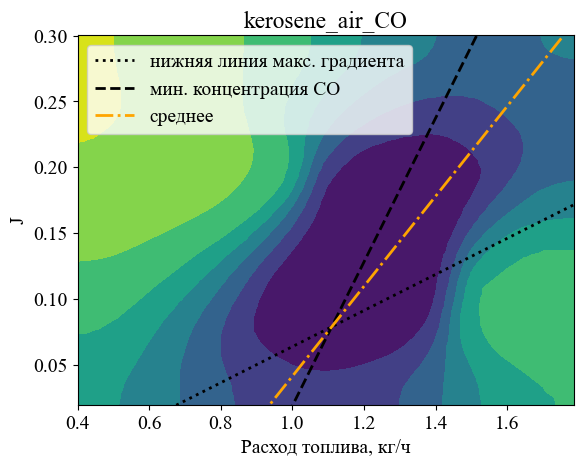

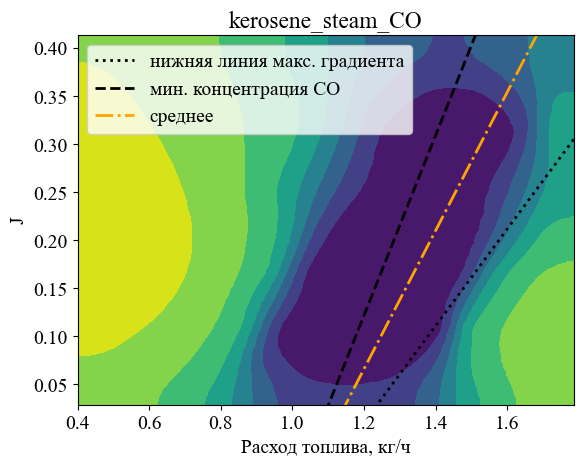

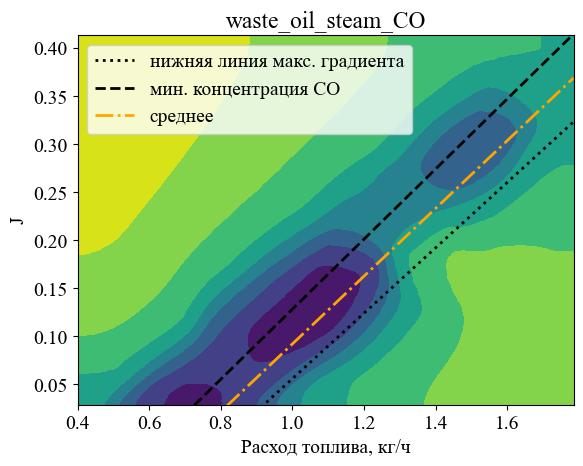

In [22]:
def show_result_with_J() -> None:
    surfs = get_rbf_data()
    surfs_J = _replace_additive_column_with_J_column(surfs)
    
    div_line_coeffs = get_linear_coeffs_div_line(get_diff_data(), 4, J=True)
    min_coeffs = get_linear_coeffs_min_CO(get_rbf_data(), J=True)
    mean_coeffs = get_mean_coeffs(div_line_coeffs, min_coeffs)
    
    for name in surfs:
        fuel_cons_J, J, diff_J = surfs_J[name]
        div_line_approx = _linear(fuel_cons_J, *div_line_coeffs[name])
        min_approx = _linear(fuel_cons_J, *min_coeffs[name])
        mean_approx = _linear(fuel_cons_J, *mean_coeffs[name])
    
        fig, ax = plt.subplots()
        plt.contourf(fuel_cons_J, J, diff_J)
        plt.plot(fuel_cons_J, div_line_approx, c='black', linestyle='dotted', linewidth=2, label='нижняя линия макс. градиента')
        plt.plot(fuel_cons_J, min_approx, c='black', linestyle='dashed', linewidth=2, label='мин. концентрация CO')
        plt.plot(fuel_cons_J, mean_approx, c='orange', linestyle='dashdot', linewidth=2, label='среднее')
        ax.set_ylabel('J')
        ax.set_xlabel('Расход топлива, кг/ч')
        plt.legend()
        plt.ylim(min(J), max(J))
        plt.title(name)
        plt.show()
        plt.close()

show_result_with_J()

C:\Users\Mark\AppData\Local\Temp\ipykernel_12300\3117077952.py:13: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


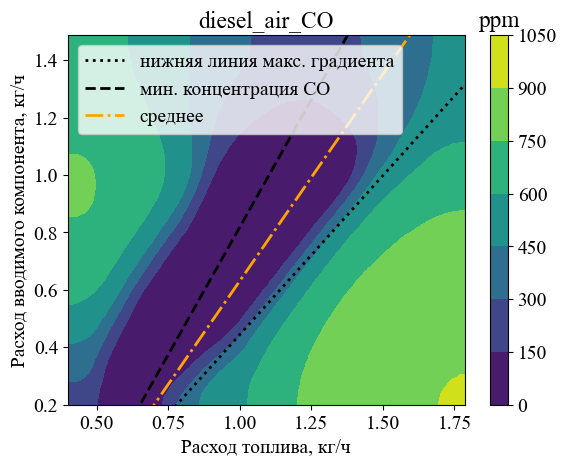

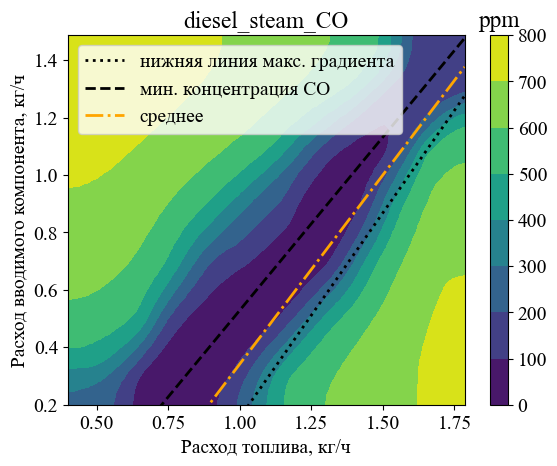

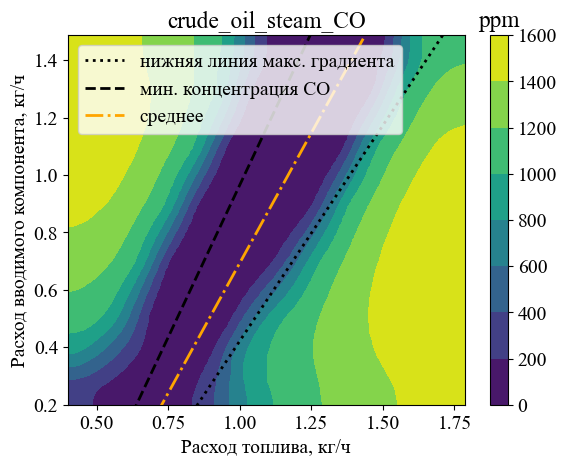

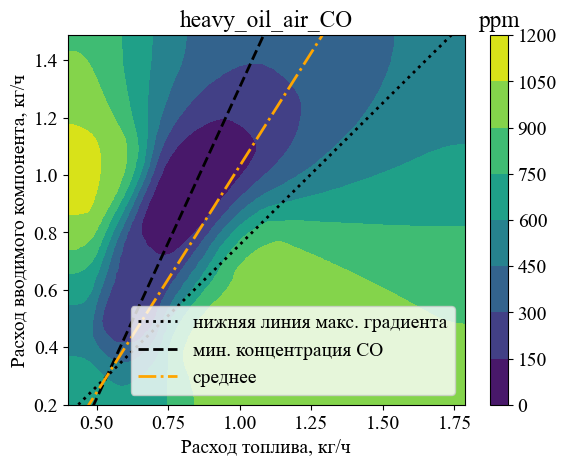

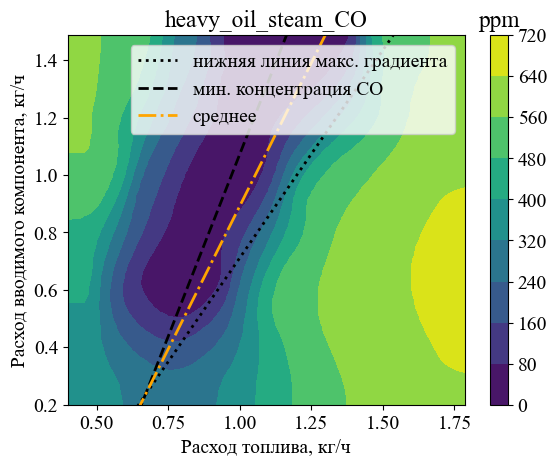

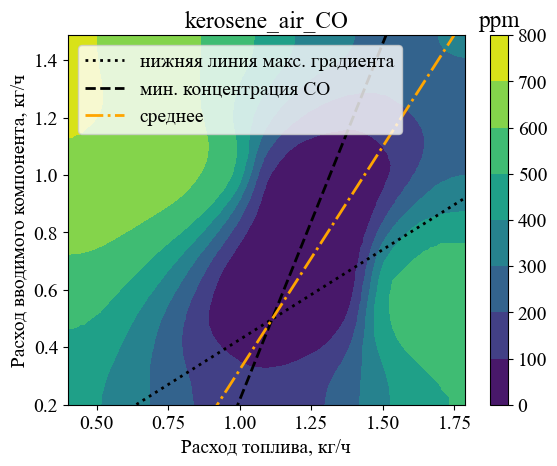

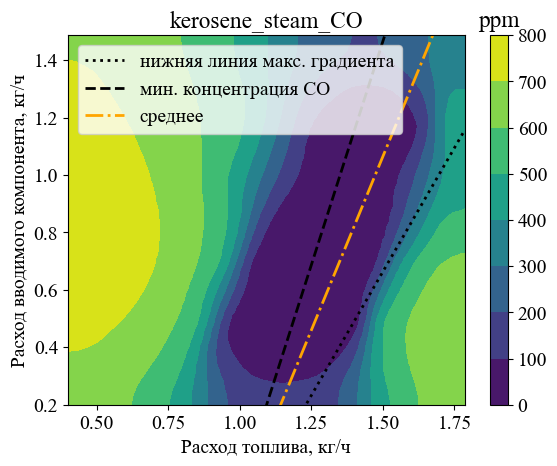

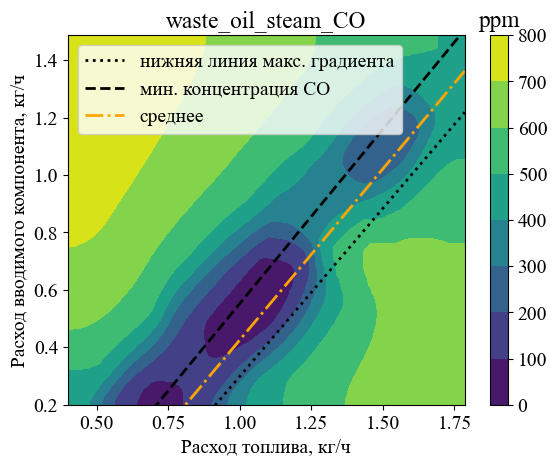

In [23]:
def show_result_equations() -> None:
    surfs = get_rbf_data()
    grad_coeffs = get_linear_coeffs_div_line(get_diff_data(), 4)
    min_coeffs = get_linear_coeffs_min_CO(surfs)
    mean_coeffs = get_mean_coeffs(grad_coeffs, min_coeffs)

    for fuel_combination in surfs:
        fuel_cons, add_cons_diff, diff = surfs[fuel_combination]
        grad_approx = _linear(fuel_cons, *grad_coeffs[fuel_combination])
        min_approx = _linear(fuel_cons, *min_coeffs[fuel_combination])
        mean_approx = _linear(fuel_cons, *mean_coeffs[fuel_combination])
        
        fig, ax = plt.subplots()
        plt.contourf(fuel_cons, add_cons_diff, diff)
        plt.plot(fuel_cons, grad_approx, c='black', linestyle='dotted', linewidth=2, label='нижняя линия макс. градиента')
        plt.plot(fuel_cons, min_approx, c='black', linestyle='dashed', linewidth=2, label='мин. концентрация CO')
        plt.plot(fuel_cons, mean_approx, c='orange', linestyle='dashdot', linewidth=2, label='среднее')
        clb = plt.colorbar()
        clb.ax.set_title('ppm')
        ax.set_xlabel('Расход топлива, кг/ч')
        ax.set_ylabel('Расход вводимого компонента, кг/ч')
        plt.legend()
        plt.ylim(min(add_cons_diff), max(add_cons_diff))
        plt.title(fuel_combination)
        plt.show()
        plt.close()
        
                                          
show_result_equations() 

# Проверка корреляции между угловым коэффициентом среднего между нижней линией максимального градиента и мин. концентрацией CO

C:\Users\Mark\AppData\Local\Temp\ipykernel_12300\3117077952.py:13: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]
C:\Users\Mark\AppData\Local\Temp\ipykernel_12300\755202035.py:10: RuntimeWarning: invalid value encountered in power
  return a * (x - b) ** c


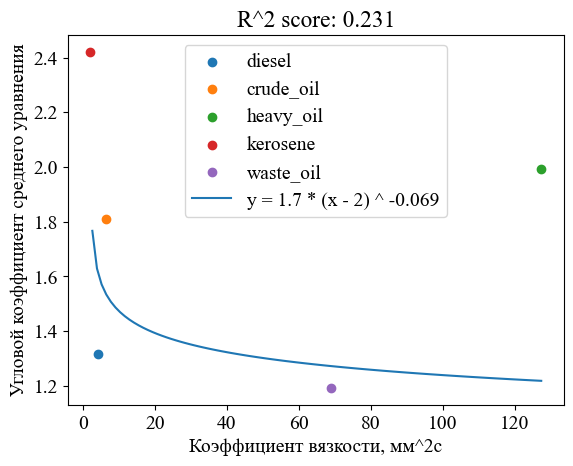

In [24]:
visc = {
    'diesel_steam_CO': 4.1,
    'crude_oil_steam_CO': 6.3,
    'heavy_oil_steam_CO': 127.4,
    'kerosene_steam_CO': 2.01,
    'waste_oil_steam_CO': 69
}

def y1(x, a = 1.7, b = 2, c = -0.069):
    return a * (x - b) ** c
    
def show_correlation():
    surfs = get_rbf_data()
    grad_coeffs = get_linear_coeffs_div_line(get_diff_data(), 4)
    min_coeffs = get_linear_coeffs_min_CO(surfs)
    mean_coeffs = get_mean_coeffs(grad_coeffs, min_coeffs)
    angle_coeffs = {}

    fig, ax = plt.subplots()
    
    for fuel_combination in surfs:
        if 'steam' in fuel_combination:
            a, b = mean_coeffs[fuel_combination]
            angle_coeffs[fuel_combination] = a
    for fuel_combination in visc:
        plt.scatter(visc[fuel_combination], angle_coeffs[fuel_combination], label=fuel_combination[:-9])

    x = np.linspace(0, max(visc.values()), 100)
    y = y1(x)
    plt.plot(x, y, label='y = 1.7 * (x - 2) ^ -0.069')
    plt.legend()
    y_true = np.array(list(angle_coeffs.values()))
    y_pred = y1(np.array(list(visc.values())))
    r2 = r2_score(y_true, y_pred)
    ax.set_xlabel('Коэффициент вязкости, мм^2с')
    ax.set_ylabel('Угловой коэффициент среднего уравнения')
    plt.title(f'R^2 score: {np.round(r2, 3)}')

show_correlation()
    

C:\Users\Mark\AppData\Local\Temp\ipykernel_12300\3117077952.py:13: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]
C:\Users\Mark\AppData\Local\Temp\ipykernel_12300\3867446539.py:2: RuntimeWarning: invalid value encountered in power
  return a * (x - b) ** c


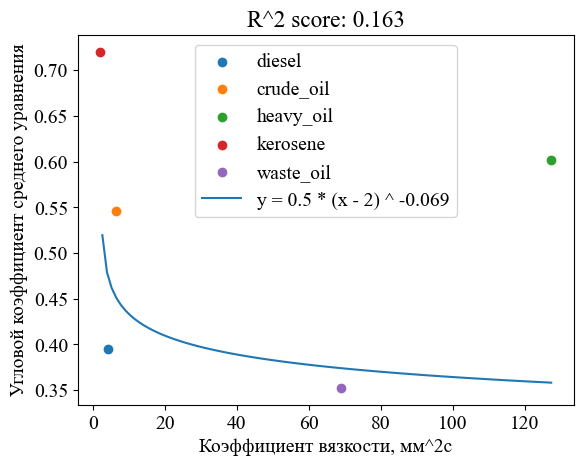

In [25]:
def y2(x, a = 0.5, b = 2, c = -0.069):
    return a * (x - b) ** c

def show_correlation_J():
    surfs = get_rbf_data()
    div_line_coeffs = get_linear_coeffs_div_line(get_diff_data(), 4, J=True)
    min_coeffs = get_linear_coeffs_min_CO(get_rbf_data(), J=True)
    mean_coeffs = get_mean_coeffs(div_line_coeffs, min_coeffs)
    angle_coeffs = {}

    fig, ax = plt.subplots()
    
    for fuel_combination in surfs:
        if 'steam' in fuel_combination:
            a, b = mean_coeffs[fuel_combination]
            angle_coeffs[fuel_combination] = a
    for fuel_combination in visc:
        plt.scatter(visc[fuel_combination], angle_coeffs[fuel_combination], label=fuel_combination[:-9])
    
    x = np.linspace(0, max(visc.values()), 100)
    y = y2(x)
    plt.plot(x, y, label='y = 0.5 * (x - 2) ^ -0.069')
    plt.legend()
    y_true = np.array(list(angle_coeffs.values()))
    y_pred = y2(np.array(list(visc.values())))
    r2 = r2_score(y_true, y_pred)
    ax.set_xlabel('Коэффициент вязкости, мм^2с')
    ax.set_ylabel('Угловой коэффициент среднего уравнения')
    plt.title(f'R^2 score: {np.round(r2, 3)}')
        

show_correlation_J()

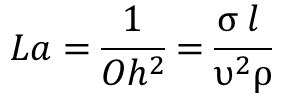

число лапласа 

# Проверка корреляции между угловым коэффициентом нижней линией максимального градиента и коэффициентом вязкости

C:\Users\Mark\AppData\Local\Temp\ipykernel_12300\3117077952.py:13: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]
C:\Users\Mark\AppData\Local\Temp\ipykernel_12300\2219297762.py:2: RuntimeWarning: invalid value encountered in power
  return a * (x - b) ** c


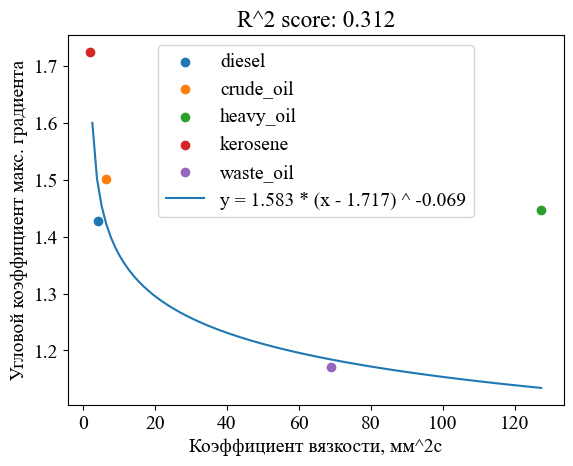

In [26]:
def y2(x, a = 1.583, b = 1.717, c = -0.069):
    return a * (x - b) ** c

def show_correlation_grad():
    surfs = get_rbf_data()
    grad_coeffs = get_linear_coeffs_div_line(get_diff_data(), 4)
    angle_coeffs = {}

    fig, ax = plt.subplots()
    
    for fuel_combination in surfs:
        if 'steam' in fuel_combination:
            a, b = grad_coeffs[fuel_combination]
            angle_coeffs[fuel_combination] = a
    for fuel_combination in visc:
        plt.scatter(visc[fuel_combination], angle_coeffs[fuel_combination], label=fuel_combination[:-9])

    x = np.linspace(0, max(visc.values()), 100)
    y = y2(x)
    plt.plot(x, y, label='y = 1.583 * (x - 1.717) ^ -0.069')
    plt.legend()
    y_true = np.array(list(angle_coeffs.values()))
    y_pred = y2(np.array(list(visc.values())))
    r2 = r2_score(y_true, y_pred)
    ax.set_xlabel('Коэффициент вязкости, мм^2с')
    ax.set_ylabel('Угловой коэффициент макс. градиента')
    plt.title(f'R^2 score: {np.round(r2, 3)}')

show_correlation_grad()

# Проверка корреляции между угловым коэффициентом нижней линией максимального градиента и числом Лапласа

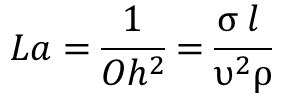

Где $\sigma$ - поверхностное натяжение,
$l$ - размер капли = $10^-5$,
$\nu$ - кинематическая вязкость,
$\rho$ - плотность при 20 С 

C:\Users\Mark\AppData\Local\Temp\ipykernel_12300\3117077952.py:13: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


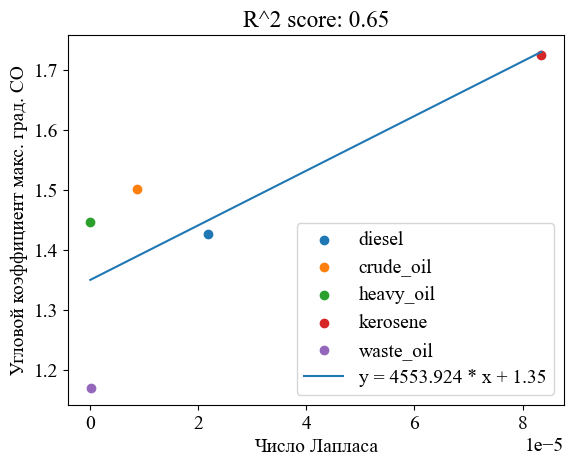

In [35]:
def get_surf_tens() -> Mapping[FuelCombination, float]:
    surf_tens = {
        'diesel_steam_CO': 30.8e3,  # поверхностное натяжение: https://additive.spb.ru/surface-tension.html
        'crude_oil_steam_CO': 28e3,  # Из диплома https://studfile.net/preview/8954587/page:7/
        'heavy_oil_steam_CO': 40e3,  # https://mostoplivo.ru/mazut/
        'kerosene_steam_CO': 26.6e3,  # поверхностное натяжение: https://additive.spb.ru/surface-tension.html
        'waste_oil_steam_CO': 20.6e3
    }
    return surf_tens

def get_density() -> Mapping[FuelCombination, float]:
    """плотность при 20"""
    dens = {
        'diesel_steam_CO': 839.89,
        'crude_oil_steam_CO': 815.61,
        'heavy_oil_steam_CO': 957.56,
        'kerosene_steam_CO': 788.89,
        'waste_oil_steam_CO': 863.25
    }
    return dens
    

def get_laplas_numbers() -> Mapping[FuelCombination, float]:
    surf_tens = get_surf_tens()
    dens = get_density()
    
    la = {}
    for fuel_combination in visc:
        la[fuel_combination] = (surf_tens[fuel_combination] * 10 ** (-5)) / ((visc[fuel_combination] ** 2) * dens[fuel_combination])
    return la
        

def show_correlation_laplas(coeffs: str='mean'):
    surfs = get_rbf_data()
    
    if coeffs == 'mean':
        grad_coeffs = get_linear_coeffs_div_line(get_diff_data(), 4)
        min_coeffs = get_linear_coeffs_min_CO(surfs)
        mean_coeffs = get_mean_coeffs(grad_coeffs, min_coeffs)
    elif coeffs == 'grad':
        grad_coeffs = get_linear_coeffs_div_line(get_diff_data(), 4)
    las = get_laplas_numbers()
    angle_coeffs = {}
    fig, ax = plt.subplots()
    
    for fuel_combination in surfs:
        if 'steam' in fuel_combination:
            if coeffs == 'mean':
                a, b = mean_coeffs[fuel_combination]
            elif coeffs == 'grad':
                a, b = grad_coeffs[fuel_combination]
            angle_coeffs[fuel_combination] = a
    for fuel_combination in las:
        plt.scatter(las[fuel_combination], angle_coeffs[fuel_combination], label=fuel_combination[:-9])

    x = np.linspace(0, max(las.values()), 100)
    
    params, _ = curve_fit(_linear, list(las.values()), list(angle_coeffs.values()))
    a_lap, b_lap = params
    y = _linear(x, a_lap, b_lap)
    plt.plot(x, y, label=f'y = {np.round(a_lap, 3)} * x + {np.round(b_lap, 3)}')
    plt.legend()
    y_true = np.array(list(angle_coeffs.values()))
    y_pred = _linear(np.array(list(las.values())), a_lap, b_lap)
    r2 = r2_score(y_true, y_pred)
    ax.set_xlabel('Число Лапласа')
    if coeffs == 'mean':
        ax.set_ylabel('Угловой коэффициент ср. уравнения')
    elif coeffs == 'grad':
        ax.set_ylabel('Угловой коэффициент макс. град. CO') 
    
    plt.title(f'R^2 score: {np.round(r2, 3)}')

show_correlation_laplas('grad')

C:\Users\Mark\AppData\Local\Temp\ipykernel_12300\3117077952.py:13: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


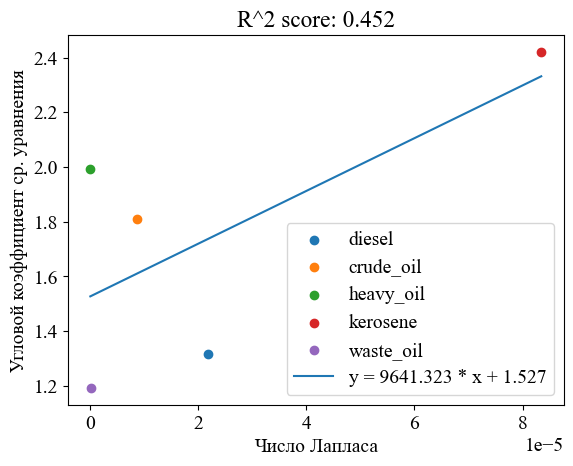

In [36]:
show_correlation_laplas()